# **성공적인 카페 상권의 조건 분석**
## 서울시 상권 데이터 기반 입지 전략 프로젝트

---

## 1. 프로젝트 개요

최근 카페 시장의 경쟁 심화로 인해 단순 유동인구 기반 입지 선정만으로는 안정적인 매출 확보가 어려워지고 있다.

이에 본 프로젝트는 서울시 상권 데이터를 활용하여 카페 매출에 영향을 미치는 핵심 요인을 분석하고, 데이터 기반의 최적 입지 전략을 도출하고자 한다.

단순히 매출을 예측하는 데 그치지 않고, EDA와 모델 해석 결과를 바탕으로 `카페 창업 및 입지 선정`에 활용 가능한 전략을 도출한다.

### **분석 목표**
1. 서울시 카페 상권의 매출 구조와 소비 패턴을 분석한다.
2. 상권 특성과 외부 환경 요인이 매출에 미치는 영향을 파악한다.
3. 머신러닝 기반 매출 예측 모델을 구축한다.
4. 핵심 변수 해석을 통해 성공 가능성이 높은 상권 특성을 도출한다.
5. 데이터 기반 카페 입지 전략을 제안한다.

※ XGBoost와 LightGBM이 설치되어 있지 않은 환경에서는 아래 명령어를 별도로 실행한다.

In [ ]:
#pip install xgboost lightgbm

## 2-1. 환경 설정 및 데이터 불러오기

분석에 필요한 라이브러리를 불러오고, 서울시 카페 상권 데이터를 로드한다.

본 프로젝트에서는 데이터 전처리 및 분석을 위해 Pandas, Numpy를 사용하였으며,
시각화를 위해 Matplotlib, Seaborn을 활용하였다.

또한 머신러닝 모델 구축 및 성능 비교를 위해 Scikit-learn, XGBoost, LightGBM 기반 모델을 사용하였다.

In [2]:
# 데이터 처리
import pandas as pd
import numpy as np

# 시각화
import matplotlib.pyplot as plt
import seaborn as sns

# 한글 폰트 설정
sns.set_style('whitegrid')
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False
# 경고 무시
import warnings
warnings.filterwarnings('ignore')

# 전처리 및 머신러닝
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (
    r2_score,
    mean_absolute_error,
    mean_squared_error
)

# 머신러닝 모델
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import Ridge, Lasso
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

## 2-2. 데이터 불러오기 및 기본 탐색

데이터의 구조와 변수 정보를 확인하고,
분석에 활용할 주요 컬럼과 타깃 변수를 점검한다.

In [3]:
# 데이터 불러오기
df = pd.read_csv('data/카페_상권_데이터.csv')
df.head(3)

,기준_년분기_코드,상권_구분_코드_명,상권_코드,상권_코드_명,분기_매출금액,총_상주인구_수,남성_상주인구_수,여성_상주인구_수,연령대_10_상주인구_수,연령대_20_상주인구_수,...,프랜차이즈_점포_수,평균 최저기온(℃),평균 최고기온(℃),총 강수량(mm),평균 풍속(m/s),평균 상대습도(%),평균 현지기압(hPa),일반음식점_점포수,자치구,행정동
0,20221,골목상권,3110002,독립문역 1번,61342892,629,309,320,79,57,...,2,-2.72,6.48,112.8,2.43,57.37,1011.91,22,종로구,무악동
1,20222,골목상권,3110002,독립문역 1번,89525560,629,309,320,79,57,...,2,14.58,24.36,421.7,2.60,61.18,1001.83,22,종로구,무악동
2,20223,골목상권,3110002,독립문역 1번,89800497,629,309,320,79,57,...,2,21.85,29.06,1018.6,2.25,75.24,998.44,21,종로구,무악동


In [4]:
print(f'데이터 행 개수: {df.shape[0]}')
print(f'데이터 열 개수: {df.shape[1]}')

df.info()

# 결측치 확인

null_data = df.isnull().sum().sort_values(ascending=False)
null_data[null_data > 0]

데이터 행 개수: 8463
데이터 열 개수: 92
<class 'pandas.DataFrame'>
RangeIndex: 8463 entries, 0 to 8462
Data columns (total 92 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   기준_년분기_코드            8463 non-null   int64  
 1   상권_구분_코드_명           8463 non-null   str    
 2   상권_코드                8463 non-null   int64  
 3   상권_코드_명              8463 non-null   str    
 4   분기_매출금액              8463 non-null   int64  
 5   총_상주인구_수             8463 non-null   int64  
 6   남성_상주인구_수            8463 non-null   int64  
 7   여성_상주인구_수            8463 non-null   int64  
 8   연령대_10_상주인구_수        8463 non-null   int64  
 9   연령대_20_상주인구_수        8463 non-null   int64  
 10  연령대_30_상주인구_수        8463 non-null   int64  
 11  연령대_40_상주인구_수        8463 non-null   int64  
 12  연령대_50_상주인구_수        8463 non-null   int64  
 13  연령대_60_이상_상주인구_수     8463 non-null   int64  
 14  남성연령대_10_상주인구_수      8463 non-null   int64  
 15  남성연령대_20_상주인구_수      

집객시설_수                 142
문화_지출_총금액               29
유흥_지출_총금액               29
여가_지출_총금액               29
식료품_지출_총금액              29
남성연령대_30_직장_인구_수         9
남성연령대_50_직장_인구_수         9
남성연령대_60_이상_직장_인구_수      9
연령대_50_직장_인구_수           9
연령대_40_직장_인구_수           9
여성연령대_60_이상_직장_인구_수      9
여성연령대_50_직장_인구_수         9
총_직장_인구_수                9
연령대_60_이상_직장_인구_수        9
남성연령대_20_직장_인구_수         9
남성연령대_10_직장_인구_수         9
여성연령대_30_직장_인구_수         9
여성연령대_40_직장_인구_수         9
연령대_30_직장_인구_수           9
연령대_20_직장_인구_수           9
여성_직장_인구_수               9
남성_직장_인구_수               9
연령대_10_직장_인구_수           9
남성연령대_40_직장_인구_수         9
여성연령대_20_직장_인구_수         9
여성연령대_10_직장_인구_수         9
남성_유동인구_수                8
총_유동인구_수                 8
목요일_유동인구_수               8
금요일_유동인구_수               8
토요일_유동인구_수               8
일요일_유동인구_수               8
연령대_40_유동인구_수            8
연령대_50_유동인구_수            8
연령대_60_이상_유동인구_수         8
시간대_00_06_유동인구_수         8
시간대_06_11_유동인구_수         8
시

일부 소비 및 유동인구 변수에서 결측치가 확인되었으나,
전체 데이터 대비 비율이 낮아 분석에는 큰 영향을 미치지 않는다고 판단하였다.

In [5]:
df['분기_매출금액'].describe()

count    8.463000e+03
mean     1.753356e+08
std      2.774912e+08
min      6.604000e+03
25%      2.706449e+07
50%      8.220634e+07
75%      1.914896e+08
max      3.599557e+09
Name: 분기_매출금액, dtype: float64

분기 매출금액은 최대 약 35억 원 수준까지 분포하고 있으며,
평균 대비 표준편차가 크게 나타나 상권별 매출 편차가 매우 큰 것으로 확인되었다.

이는 일부 핵심 상권에 매출이 집중되는 현상이 존재함을 시사한다.

### **주요 변수 구성**

| 변수 유형 | 예시 |
|---|---|
| 매출 변수 | 분기_매출금액 |
| 상권 변수 | 점포수, 프랜차이즈 점포수 |
| 인구 변수 | 유동인구, 상주인구, 직장인구 |
| 소비 변수 | 월평균소득 |
| 환경 변수 | 기온, 강수량, 습도 |

## 2-3. 시간 변수 전처리

원본 데이터의 `기준_년분기_코드`는 연도와 분기 정보가 결합된 형태로 구성되어 있었다.

연도와 분기 변수는
카페 소비의 `계절성 및 시계열 흐름`을 반영하기 위해 분리하였다.

또한 분석에 직접적으로 활용되지 않는 불필요 컬럼은 제거하여 데이터 구조를 단순화하였다.

In [6]:
# 기준년분기코드 → 연도 / 분기 분리
df['년도'] = df['기준_년분기_코드'].astype(str).str[:4].astype(str)
df['분기'] = df['기준_년분기_코드'].astype(str).str[-1].astype(str)

# 기존 컬럼 제거
df.drop(columns=['기준_년분기_코드'], inplace=True)

# 불필요 컬럼 제거
df.drop(columns=['상권_구분_코드_명'], inplace=True)

# 컬럼 순서 재배치
front_columns = ['년도', '분기']
remaining_columns = [col for col in df.columns if col not in front_columns]

df = df[front_columns + remaining_columns]

df.head(2)

,년도,분기,상권_코드,상권_코드_명,분기_매출금액,총_상주인구_수,남성_상주인구_수,여성_상주인구_수,연령대_10_상주인구_수,연령대_20_상주인구_수,...,프랜차이즈_점포_수,평균 최저기온(℃),평균 최고기온(℃),총 강수량(mm),평균 풍속(m/s),평균 상대습도(%),평균 현지기압(hPa),일반음식점_점포수,자치구,행정동
0,2022,1,3110002,독립문역 1번,61342892,629,309,320,79,57,...,2,-2.72,6.48,112.8,2.43,57.37,1011.91,22,종로구,무악동
1,2022,2,3110002,독립문역 1번,89525560,629,309,320,79,57,...,2,14.58,24.36,421.7,2.60,61.18,1001.83,22,종로구,무악동


## 2-4. 분석 대상 데이터 필터링

일부 상권은 특정 분기 데이터가 누락되어 있었으며,
이 경우 시계열 흐름 및 계절성 패턴이 왜곡될 가능성이 존재하였다.

따라서 2022~2024년 전체 12개 분기 데이터를 모두 보유한 상권만 분석 대상으로 선정하였다.

In [7]:
# 상권별 보유 분기 수 확인
record_counts = df.groupby('상권_코드').size()

# 12개 분기 데이터를 모두 보유한 상권만 추출
valid_codes = record_counts[record_counts == 12].index

# 완전한 시계열 데이터를 가진 상권만 필터링
df = df[df['상권_코드'].isin(valid_codes)].copy()

# 열 이름 변경
df.rename(columns={'총_점포_수': '총_커피매장_수'}, inplace=True)

print(f'필터링 후 데이터 크기: {df.shape}')
print(df.head())
record_counts = df.groupby('상권_코드').size()
# 검증
print(record_counts.min())
print(record_counts.max())


필터링 후 데이터 크기: (7404, 92)
     년도 분기    상권_코드  상권_코드_명   분기_매출금액  총_상주인구_수  남성_상주인구_수  여성_상주인구_수  \
0  2022  1  3110002  독립문역 1번  61342892       629        309        320   
1  2022  2  3110002  독립문역 1번  89525560       629        309        320   
2  2022  3  3110002  독립문역 1번  89800497       629        309        320   
3  2022  4  3110002  독립문역 1번  75913905       663        326        337   
4  2022  1  3110003  세검정초등학교  55734579      3212       1505       1707   

   연령대_10_상주인구_수  연령대_20_상주인구_수  ...  프랜차이즈_점포_수  평균 최저기온(℃)  평균 최고기온(℃)  \
0             79             57  ...           2       -2.72        6.48   
1             79             57  ...           2       14.58       24.36   
2             79             57  ...           2       21.85       29.06   
3             52             60  ...           2        3.06       12.22   
4            603            399  ...           0       -2.72        6.48   

   총 강수량(mm)  평균 풍속(m/s)  평균 상대습도(%)  평균 현지기압(hPa)  일반음식점_점포수  자치구  행정동  

## 2-5. 변수 구조 정리

분석 효율성과 가독성을 높이기 위해 변수를 기능별로 재정렬하였다.


In [8]:
order = [
    # 1. 기본 정보 (Identifiers & Location)
    '년도',
    '분기',
    '상권_코드',
    '상권_코드_명',
    '자치구',
    '행정동',

    # 2. 상권 및 점포 정보
    '총_커피매장_수',
    '일반_점포_수',
    '프랜차이즈_점포_수',
    '일반음식점_점포수',
    '상권_변화_지표_명',
    '운영_영업_개월_평균',
    '폐업_영업_개월_평균',
    '서울_운영_영업_개월_평균',
    '서울_폐업_영업_개월_평균',
    '집객시설_수',

    # 3. 상주인구 정보
    '총_상주인구_수',
    '남성_상주인구_수',
    '여성_상주인구_수',
    '연령대_10_상주인구_수',
    '연령대_20_상주인구_수',
    '연령대_30_상주인구_수',
    '연령대_40_상주인구_수',
    '연령대_50_상주인구_수',
    '연령대_60_이상_상주인구_수',
    '남성연령대_10_상주인구_수',
    '남성연령대_20_상주인구_수',
    '남성연령대_30_상주인구_수',
    '남성연령대_40_상주인구_수',
    '남성연령대_50_상주인구_수',
    '남성연령대_60_이상_상주인구_수',
    '여성연령대_10_상주인구_수',
    '여성연령대_20_상주인구_수',
    '여성연령대_30_상주인구_수',
    '여성연령대_40_상주인구_수',
    '여성연령대_50_상주인구_수',
    '여성연령대_60_이상_상주인구_수',

    # 4. 직장인구 정보
    '총_직장_인구_수',
    '남성_직장_인구_수',
    '여성_직장_인구_수',
    '연령대_10_직장_인구_수',
    '연령대_20_직장_인구_수',
    '연령대_30_직장_인구_수',
    '연령대_40_직장_인구_수',
    '연령대_50_직장_인구_수',
    '연령대_60_이상_직장_인구_수',
    '남성연령대_10_직장_인구_수',
    '남성연령대_20_직장_인구_수',
    '남성연령대_30_직장_인구_수',
    '남성연령대_40_직장_인구_수',
    '남성연령대_50_직장_인구_수',
    '남성연령대_60_이상_직장_인구_수',
    '여성연령대_10_직장_인구_수',
    '여성연령대_20_직장_인구_수',
    '여성연령대_30_직장_인구_수',
    '여성연령대_40_직장_인구_수',
    '여성연령대_50_직장_인구_수',
    '여성연령대_60_이상_직장_인구_수',

    # 5. 유동인구 정보
    '총_유동인구_수',
    '남성_유동인구_수',
    '여성_유동인구_수',
    '연령대_10_유동인구_수',
    '연령대_20_유동인구_수',
    '연령대_30_유동인구_수',
    '연령대_40_유동인구_수',
    '연령대_50_유동인구_수',
    '연령대_60_이상_유동인구_수',
    '시간대_00_06_유동인구_수',
    '시간대_06_11_유동인구_수',
    '시간대_11_14_유동인구_수',
    '시간대_14_17_유동인구_수',
    '시간대_17_21_유동인구_수',
    '시간대_21_24_유동인구_수',
    '월요일_유동인구_수',
    '화요일_유동인구_수',
    '수요일_유동인구_수',
    '목요일_유동인구_수',
    '금요일_유동인구_수',
    '토요일_유동인구_수',
    '일요일_유동인구_수',

    # 6. 소득 및 지출 정보
    '월_평균_소득_금액',
    '식료품_지출_총금액',
    '여가_지출_총금액',
    '문화_지출_총금액',
    '유흥_지출_총금액',
    
    # 7. 날씨 정보 (외부 요인)
    '평균 최저기온(℃)',
    '평균 최고기온(℃)',
    '총 강수량(mm)',
    '평균 풍속(m/s)',
    '평균 상대습도(%)',
    '평균 현지기압(hPa)',

    # 8. 타겟 변수 (Target Variable)
    '분기_매출금액'
]

df = df[[col for col in order if col in df.columns]]

### **변수 그룹 구성**

| 변수 그룹 | 설명 |
|---|---|
| 기본 정보 | 연도, 분기, 상권 위치 정보 |
| 상권 및 점포 정보 | 점포 수, 상권 변화 지표 |
| 상주인구 정보 | 거주 인구 특성 |
| 직장인구 정보 | 업무 목적 유입 인구 |
| 유동인구 정보 | 시간대 및 요일별 이동 인구 |
| 소비 정보 | 소득 및 소비 규모 |
| 날씨 정보 | 기온, 강수량 등 외부 환경 변수 |
| 타겟 변수 | 분기 매출금액 |

#  **탐색적 데이터 분석(EDA)**

## 3-0. 타깃 변수 분포 분석

본 프로젝트의 예측 대상 변수는 `분기_매출금액`이다.

모델링에 앞서 타깃 변수의 분포를 확인하여 매출 데이터의 전반적인 규모, 편차, 이상치 존재 여부를 파악하였다.  
카페 상권 매출은 일부 핵심 상권에 집중될 가능성이 있으므로, 평균값뿐 아니라 분포의 형태를 함께 확인할 필요가 있다.

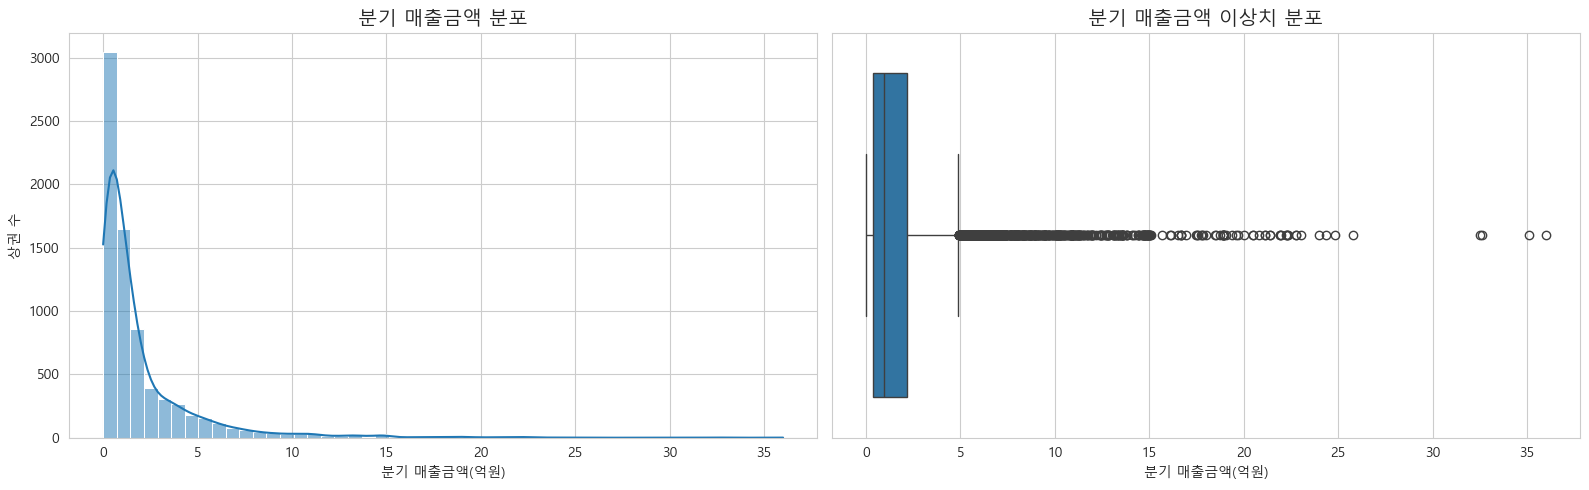

In [9]:
# 타깃 변수 분포 확인
target = '분기_매출금액'

# 억 원 단위 변환
df['분기_매출금액_억원'] = df[target] / 100000000

# 기초 통계량 확인
df['분기_매출금액_억원'].describe()

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# 1. 히스토그램
sns.histplot(
    data=df,
    x='분기_매출금액_억원',
    bins=50,
    kde=True,
    ax=axes[0]
)

axes[0].set_title('분기 매출금액 분포', fontsize=14)
axes[0].set_xlabel('분기 매출금액(억원)')
axes[0].set_ylabel('상권 수')

# 2. 박스플롯
sns.boxplot(
    data=df,
    x='분기_매출금액_억원',
    ax=axes[1]
)

axes[1].set_title('분기 매출금액 이상치 분포', fontsize=14)
axes[1].set_xlabel('분기 매출금액(억원)')

plt.tight_layout()
plt.show()

### 분석 결과

분기 매출금액 분포를 확인한 결과, 오른쪽으로 긴 꼬리(right-skewed)를 가진 형태가 나타났다.

이는 대부분의 상권이 낮거나 중간 수준의 매출 구간에 분포하는 반면, 일부 핵심 상권은 매우 높은 매출을 기록하고 있음을 의미한다.

또한 박스플롯에서도 고매출 이상치가 다수 확인되어, 상권별 매출 편차가 크다는 점을 확인할 수 있었다.

따라서 **카페 매출은 특정 핵심 상권에 집중되는 경향이 존재하며, 이후 모델링 과정에서는 단순 평균 매출뿐 아니라 상권 규모, 점포 수, 인구 구조, 소비 수준 등 다양한 설명 변수를 함께 고려할 필요가 있다.**

## 3-1. 연도 및 분기별 매출 추이 분석

시간 흐름에 따라 카페 매출이 어떻게 변화하는지 확인하기 위해
연도 및 분기 기준 평균 매출 추이를 분석하였다.

이를 통해 계절성 및 외부 환경 변화가 매출에 미치는 영향을 파악하고자 하였다.

In [10]:
# 년도별 평균 매출
yearly_sales = df.groupby('년도')['분기_매출금액'].mean().reset_index()
# 년도 및 분기별 평균 매출
quarter_sales = (
    df.groupby(['년도', '분기'])['분기_매출금액']
    .mean()
    .reset_index()
)

quarter_sales['연도_분기'] = (
    quarter_sales['년도'].astype(str) + '-Q' +
    quarter_sales['분기'].astype(str)
)

quarter_sales.head()

,년도,분기,분기_매출금액,연도_분기
0,2022,1,1.591795e+08,2022-Q1
1,2022,2,2.051139e+08,2022-Q2
2,2022,3,1.969933e+08,2022-Q3
3,2022,4,1.930118e+08,2022-Q4
4,2023,1,1.860810e+08,2023-Q1


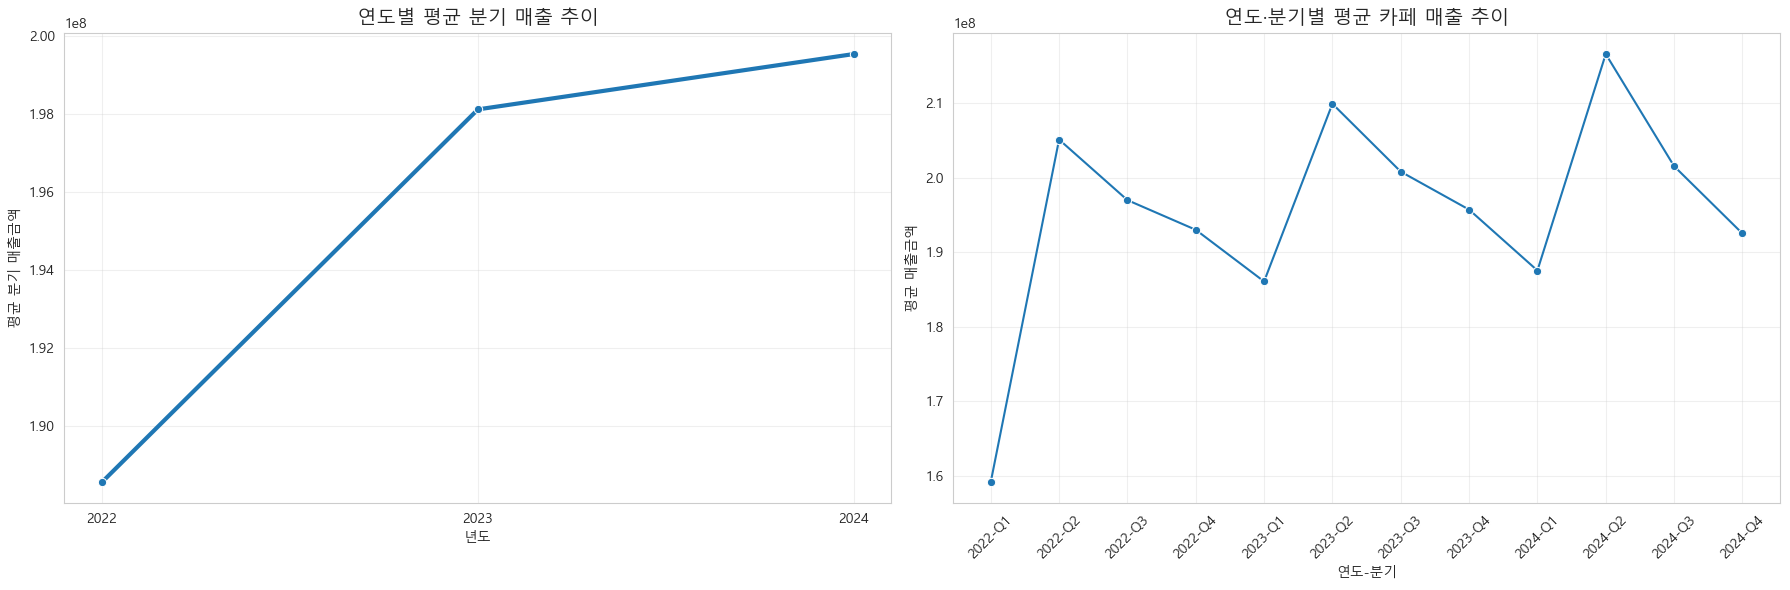

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(18,6))

# 1. 연도별 평균 매출
sns.lineplot(
    data=yearly_sales,
    x='년도',
    y='분기_매출금액',
    marker='o',
    linewidth=3,
    ax=axes[0]
)

axes[0].set_title('연도별 평균 분기 매출 추이', fontsize=14)
axes[0].set_xlabel('년도')
axes[0].set_ylabel('평균 분기 매출금액')

axes[0].grid(True, alpha=0.3)

# 2. 연도-분기별 평균 매출
sns.lineplot(
    data=quarter_sales,
    
    x='연도_분기',
    y='분기_매출금액',
    marker='o',
    ax=axes[1]
)

axes[1].set_title('연도·분기별 평균 카페 매출 추이', fontsize=14)
axes[1].set_xlabel('연도-분기')
axes[1].set_ylabel('평균 매출금액')

axes[1].tick_params(axis='x', rotation=45)

axes[1].grid(True, alpha=0.3)

plt.tight_layout()

plt.show()

### 분석 결과

연도 및 분기별 평균 매출 추이를 확인한 결과, 1분기에는 상대적으로 매출이 감소하고 2분기에는 매출이 증가하는 반복 패턴이 나타났다.

특히 2분기 매출이 매년 높은 수준을 보이는 것으로 나타나, 카페 산업은 계절성과 외부 활동 증가의 영향을 받는 업종임을 확인할 수 있었다.

또한 연도별 평균 매출 수준은 2022년 이후 점진적으로 증가하는 흐름을 보였다.
이는 분석 대상 상권에서 카페 매출 수준이 전반적으로 상승하는 경향이 존재함을 시사한다.

따라서 **연도 및 분기 변수는 카페 매출 예측 모델에서 계절성과 시계열 흐름을 반영하는 주요 설명 변수로 활용할 필요가 있다.**

## 3-2. (COVID-19)거리두기 해제 전·후 매출 비교


카페 산업은 대면 소비와 외부 활동의 영향을 크게 받는 업종이다.

따라서 사회적 거리두기 완화 이후 오프라인 소비 회복이 카페 매출 증가와 연결되었을 가능성을 확인하고자 한다.

In [12]:
df['년도'] = pd.to_numeric(df['년도'], errors='coerce')
df['분기'] = pd.to_numeric(df['분기'], errors='coerce')
df['분기_매출금액'] = pd.to_numeric(df['분기_매출금액'], errors='coerce')

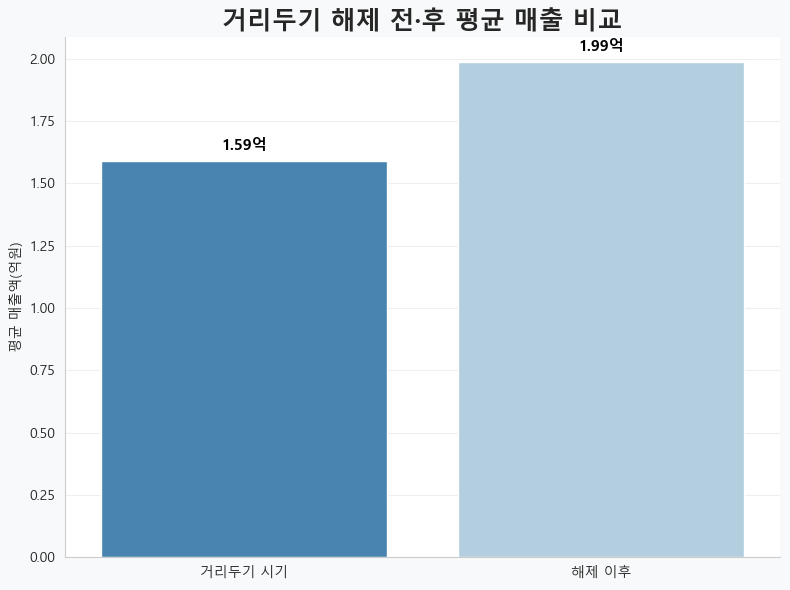

In [13]:
# 거리두기 해제 여부 변수 생성
df['거리두기_해제_이후'] = np.where(
    (df['년도'] == 2022) & (df['분기'] < 2),
    0,
    1
)

# 억원 단위 변환
df['분기_매출금액_억원'] = df['분기_매출금액'] / 100000000

# 거리두기 해제 전·후 평균 매출 계산
covid_sales = (
    df.groupby('거리두기_해제_이후')['분기_매출금액_억원']
    .mean()
    .reset_index()
)

# 시각화
fig, ax = plt.subplots(figsize=(8, 6))

fig.patch.set_facecolor('#f8f9fa')

barplot = sns.barplot(
    x='거리두기_해제_이후',
    y='분기_매출금액_억원',
    data=covid_sales,
    palette='Blues_r',
    ax=ax
)

# 막대 위 수치 표시
for p in barplot.patches:

    height = p.get_height()

    barplot.annotate(
        f'{height:.2f}억',
        (p.get_x() + p.get_width() / 2., height),
        ha='center',
        va='bottom',
        fontsize=11,
        fontweight='bold',
        color='black',
        xytext=(0, 5),
        textcoords='offset points'
    )

# 제목 및 라벨
ax.set_title(
    '거리두기 해제 전·후 평균 매출 비교',
    fontsize=18,
    fontweight='bold'
)

ax.set_xlabel('')
ax.set_ylabel('평균 매출액(억원)')

# x축 라벨 변경
ax.set_xticks([0, 1])

ax.set_xticklabels([
    '거리두기 시기',
    '해제 이후'
])

# grid 스타일
ax.grid(axis='y', alpha=0.3)

# 테두리 제거
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()

plt.show()

### 분석 결과

거리두기 해제 이후 평균 매출 수준은 이전 시기 대비 높게 나타났다.

이는 외부 활동 증가와 대면 소비 회복이 카페 매출 증가에 긍정적인 영향을 미쳤을 가능성을 시사한다.

다만 본 분석은 단순 평균 비교 기반으로 수행되었으며, 계절성·물가 상승·소비 트렌드 변화 등 다양한 외부 요인이 함께 작용했을 가능성이 존재한다.

따라서 본 결과는 거리두기 해제의 직접 효과라기보다, 외부 환경 변화에 따른 소비 회복 흐름으로 해석하는 것이 적절하다.

## 3-3. 날씨 변수와 매출 관계 분석

카페 산업은 계절성과 외부 활동의 영향을 크게 받는 업종이므로,
날씨 요인이 매출 변화와 어떤 관계를 가지는지 분석하였다.

이를 위해 기온, 강수량, 풍속, 습도, 기압 등 주요 기상 변수와
분기 매출금액 간의 상관관계를 확인하였다.

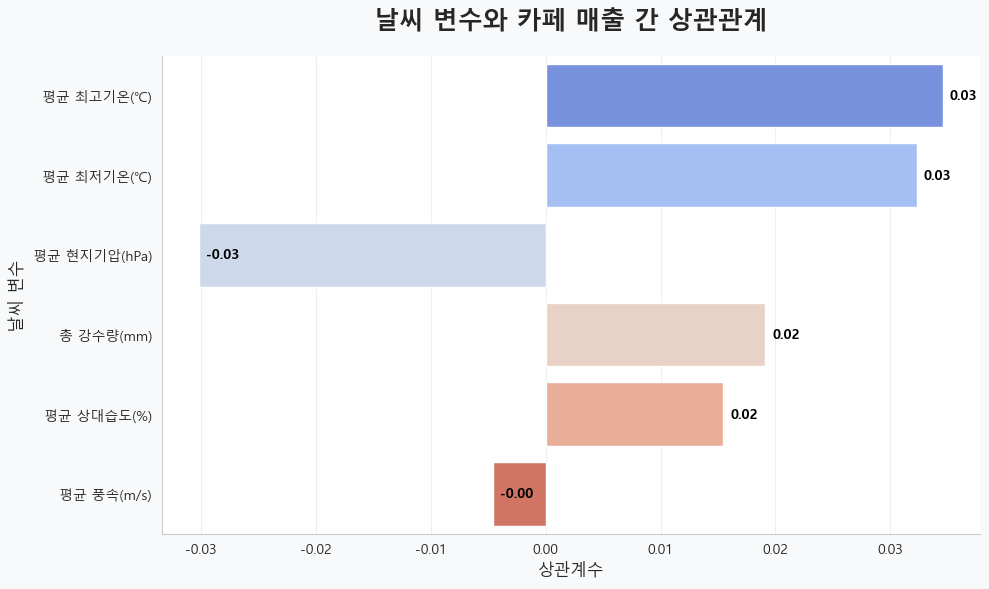

In [14]:
# 날씨 변수
weather = [
    '평균 최저기온(℃)',
    '평균 최고기온(℃)',
    '총 강수량(mm)',
    '평균 풍속(m/s)',
    '평균 상대습도(%)',
    '평균 현지기압(hPa)'
]

# 상관계수 계산
correlations = df[weather + ['분기_매출금액']].corr(method='pearson')

sales_corr = correlations['분기_매출금액'].drop('분기_매출금액')

# 절댓값 기준 정렬
strongest_corr = sales_corr.reindex(
    sales_corr.abs().sort_values(ascending=False).index
)

strongest_corr_df = strongest_corr.to_frame(name='Correlation')

# figure 생성
fig, ax = plt.subplots(figsize=(10, 6))

fig.patch.set_facecolor('#f8f9fa')

# 막대 그래프
barplot = sns.barplot(
    x='Correlation',
    y=strongest_corr_df.index,
    data=strongest_corr_df,
    palette='coolwarm',
    ax=ax
)

# 값 표시
for p in barplot.patches:

    width = p.get_width()

    barplot.annotate(
        f'{width:.2f}',
        (width, p.get_y() + p.get_height() / 2),
        ha='left',
        va='center',
        fontsize=10,
        fontweight='bold',
        color='black',
        xytext=(5, 0),
        textcoords='offset points'
    )

# 제목 및 라벨
ax.set_title(
    '날씨 변수와 카페 매출 간 상관관계',
    fontsize=18,
    fontweight='bold',
    pad=20
)

ax.set_xlabel('상관계수', fontsize=12)
ax.set_ylabel('날씨 변수', fontsize=12)

# grid 스타일
ax.grid(axis='x', alpha=0.3)

# 축 스타일 제거
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()

plt.show()

### 분석 결과

날씨 변수와 분기 매출금액 간 상관관계를 확인한 결과, 모든 변수의 상관계수는 -0.03 ~ 0.03 수준으로 나타났다.

이는 분기 단위 데이터 기준에서는 날씨 변수와 카페 매출 간의 뚜렷한 선형 관계가 확인되지 않았음을 의미한다.

특히 **카페 매출은 단기적 기상 변화보다 상권 규모, 유동인구, 직장인구, 소비 수준과 같은 구조적 요인의 영향을 더 크게 받을 가능성이 존재한다.**

다만 본 분석은 분기 단위 집계 데이터 기반의 선형 상관분석으로 수행되었으므로, 일별 기상 변화나 비선형 관계까지는 충분히 반영하지 못할 수 있다.

### **분석의 한계 및 확장 가능**

연도별 평균 매출이 증가하는 흐름이 확인되었으나, 이는 실제 수요 증가뿐 아니라 물가 상승에 따른 명목 매출 증가가 함께 반영되었을 가능성이 존재한다.

따라서 향후에는 소비자물가지수(CPI)를 활용한 실질 매출 보정이나, 연도별 커피 소비량 데이터를 함께 활용할 경우 시장 성장 여부를 보다 정교하게 분석할 수 있을 것이다.

다만 본 프로젝트에서는 상권 특성과 매출 예측 모델 구축에 집중하기 위해, 해당 분석은 향후 확장 가능성으로 남겨두었다.

## 3-4. 상권 변화 지표별 매출 분석

상권의 성장·축소·정체 여부에 따라 카페 매출 수준이 달라지는지 확인하기 위해,
상권 변화 지표별 매출 분포와 분기별 매출 추이를 비교하였다.

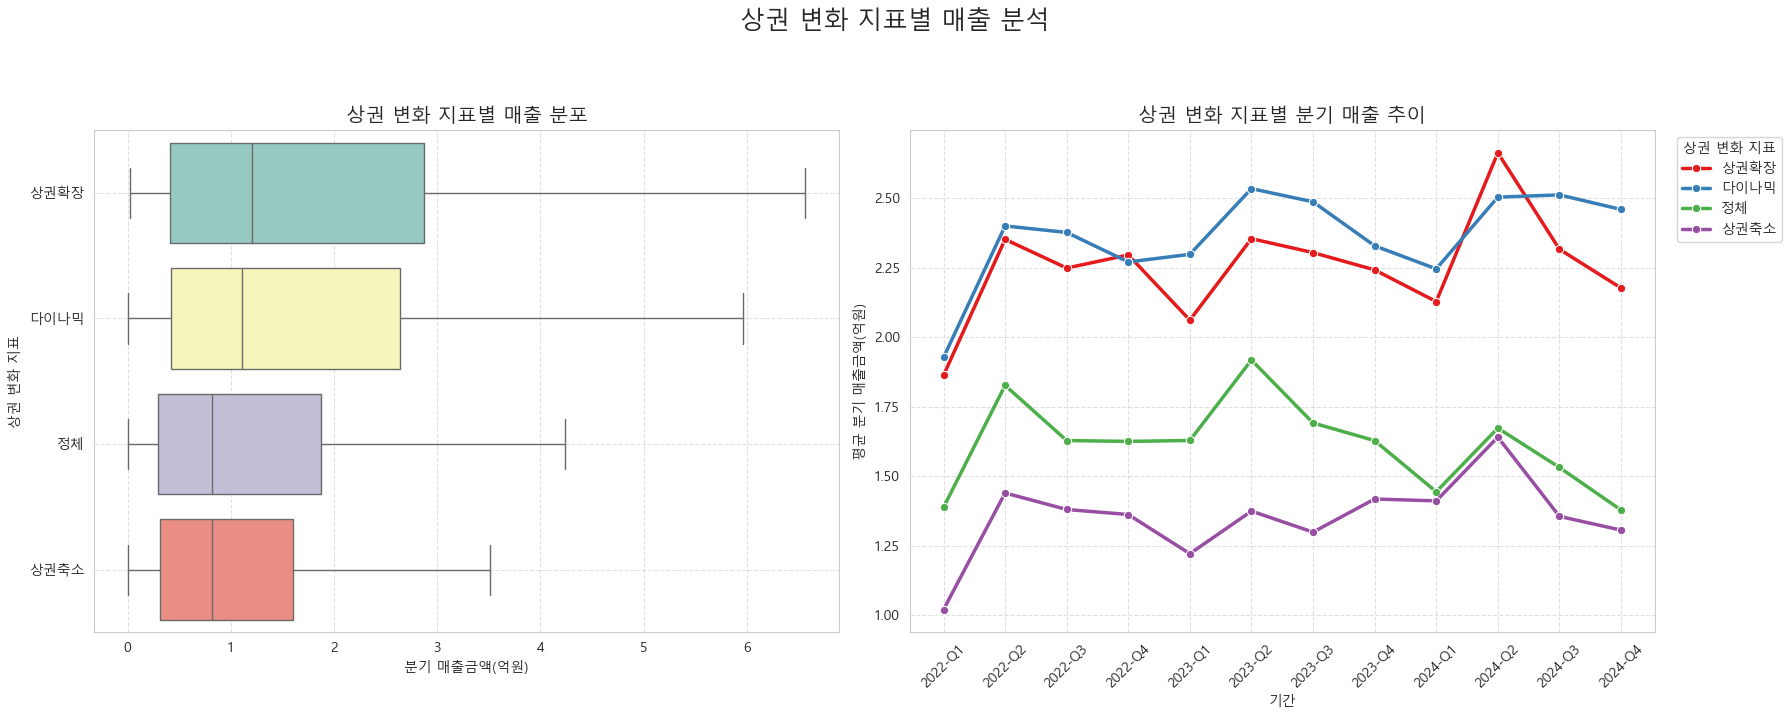

In [15]:
market_change_df = df.copy()

# 기간 변수 생성
market_change_df['기간'] = (
    market_change_df['년도'].astype(str) + '-Q' +
    market_change_df['분기'].astype(str)
)

# 억 원 단위 변환
market_change_df['분기_매출금액_억원'] = market_change_df['분기_매출금액'] / 100000000

# 정렬
market_change_df = market_change_df.sort_values(by=['년도', '분기'])

# 상권 변화 지표 순서 지정
change_order = ['상권확장', '다이나믹', '정체', '상권축소']

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle('상권 변화 지표별 매출 분석', fontsize=18, y=1.02)

# 1. 매출 분포
sns.boxplot(
    ax=axes[0],
    data=market_change_df,
    y='상권_변화_지표_명',
    x='분기_매출금액_억원',
    order=change_order,
    hue='상권_변화_지표_명',
    hue_order=change_order,
    palette='Set3',
    showfliers=False,
    legend=False
)

axes[0].set_title('상권 변화 지표별 매출 분포', fontsize=14)
axes[0].set_xlabel('분기 매출금액(억원)')
axes[0].set_ylabel('상권 변화 지표')
axes[0].grid(True, linestyle='--', alpha=0.6)

# 2. 매출 추이
sns.lineplot(
    ax=axes[1],
    data=market_change_df,
    x='기간',
    y='분기_매출금액_억원',
    hue='상권_변화_지표_명',
    hue_order=change_order,
    palette='Set1',
    linewidth=2.5,
    marker='o',
    errorbar=None
)

axes[1].set_title('상권 변화 지표별 분기 매출 추이', fontsize=14)
axes[1].set_xlabel('기간')
axes[1].set_ylabel('평균 분기 매출금액(억원)')
axes[1].tick_params(axis='x', rotation=45)
axes[1].grid(True, linestyle='--', alpha=0.6)

axes[1].legend(
    title='상권 변화 지표',
    bbox_to_anchor=(1.02, 1),
    loc='upper left'
)

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

### 분석 결과

상권 변화 지표별로 매출 분포와 추이에 차이가 나타났다.

특히 다이나믹 또는 상권확장 유형의 상권은 상대적으로 높은 매출 수준을 보이는 경향이 있으며,
이는 상권 활성도와 성장성이 카페 매출에 영향을 미칠 가능성을 시사한다.

반면 상권축소 또는 정체 유형은 상대적으로 낮은 매출 구간에 분포하는 경향이 있어,
입지 선정 시 상권의 현재 규모뿐 아니라 변화 방향성도 함께 고려할 필요가 있다.

- 상권확장(LH): 신규 점포 유입이 활발하며, 상권 규모가 성장하는 유형
- 정체(HH): 개·폐업 변화가 크지 않아 비교적 안정적인 상권 유형
- 상권축소(HL): 폐업률이 상대적으로 높아 상권 규모가 감소하는 유형
- 다이나믹(LL): 개·폐업이 모두 활발하게 발생하는 변동성이 높은 상권 유형

## 3-5. 상권 안정성과 매출 관계 분석

상권의 운영 지속 기간과 폐업 특성은
상권 안정성과 시장 경쟁 강도를 반영할 가능성이 존재한다.

이에 따라 운영 기간 및 폐업 기간과 매출 간의 관계를 분석하였다.

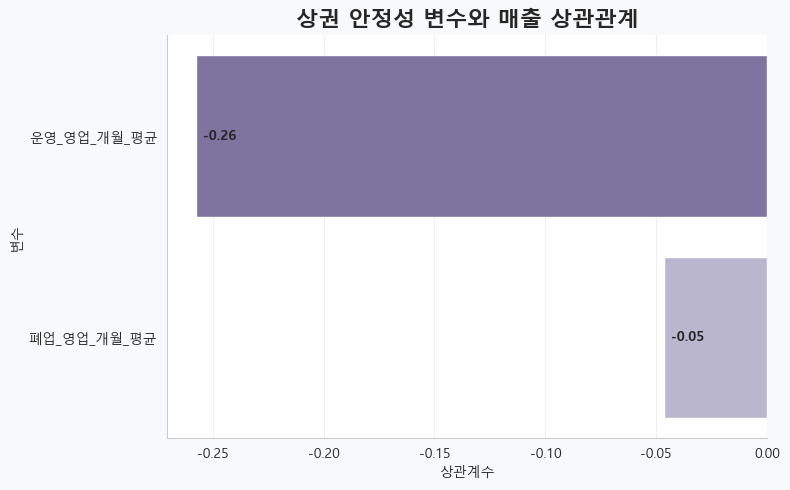

In [16]:
stability_features = [
    '운영_영업_개월_평균',
    '폐업_영업_개월_평균'
]

stability_corr = (
    df[stability_features + ['분기_매출금액']]
    .corr(method='pearson')
)

sales_corr = stability_corr['분기_매출금액'].drop('분기_매출금액')

sales_corr_df = sales_corr.to_frame(name='Correlation')

fig, ax = plt.subplots(figsize=(8, 5))

fig.patch.set_facecolor('#f8f9fa')

barplot = sns.barplot(
    x='Correlation',
    y=sales_corr_df.index,
    data=sales_corr_df,
    palette=['#7B6BA8', '#B8B2D1'],
    ax=ax
)

# 값 표시
for p in barplot.patches:

    width = p.get_width()

    barplot.annotate(
        f'{width:.2f}',
        (width, p.get_y() + p.get_height() / 2),
        ha='left',
        va='center',
        fontsize=10,
        fontweight='bold',
        xytext=(5, 0),
        textcoords='offset points'
    )

ax.set_title(
    '상권 안정성 변수와 매출 상관관계',
    fontsize=16,
    fontweight='bold'
)

ax.set_xlabel('상관계수')
ax.set_ylabel('변수')

ax.grid(axis='x', alpha=0.3)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()

plt.show()

### 분석 결과

운영 영업 개월 평균은 분기 매출금액과 약한 음의 상관관계(-0.26)를 나타냈다.

이는 운영 기간이 긴 상권일수록 반드시 높은 매출을 기록하는 것은 아니며, 일부 성숙 상권에서는 성장성이 둔화되었을 가능성이 존재함을 시사한다.

반면 신규 점포 유입이 활발한 성장형 상권은 운영 기간이 상대적으로 짧더라도 높은 매출 수준을 보일 가능성이 있다.

한편 폐업 영업 개월 평균은 매출과의 상관관계가 매우 낮게 나타나(-0.05), 단일 변수만으로 카페 매출 수준을 충분히 설명하기는 어려운 것으로 확인되었다.

## 3-6. 상권 생애주기별 매출 분포 분석

운영 영업 개월 평균을 기준으로 상권의 생애주기를 구분하고,
단계별 매출 분포 차이를 추가적으로 분석하였다.

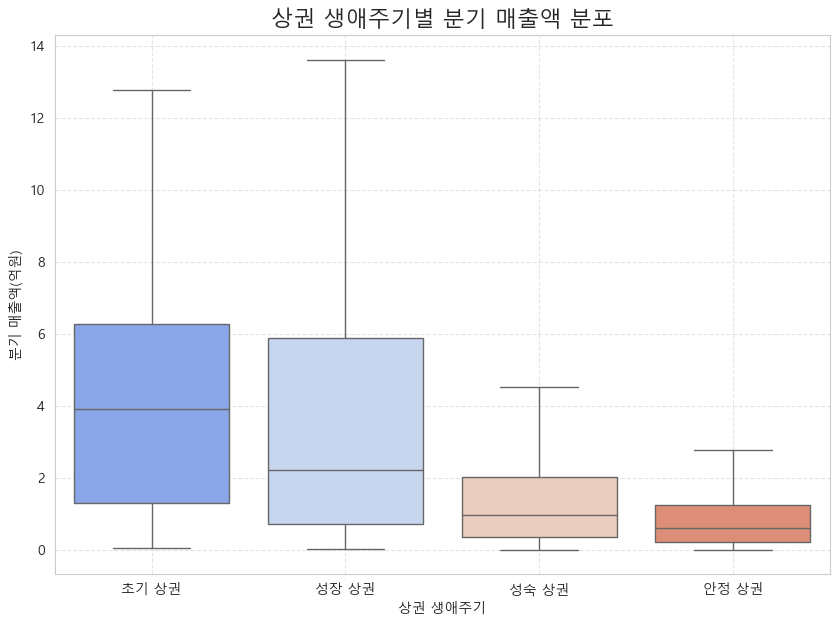

In [17]:
# 운영 기간 기준 상권 생애주기 구분
bins = [0, 60, 80, 120, float('inf')]
labels = ['초기 상권', '성장 상권', '성숙 상권', '안정 상권']

df['상권_생애주기'] = pd.cut(
    df['운영_영업_개월_평균'],
    bins=bins,
    labels=labels,
    right=False
)

# 억 원 단위 변환
df['분기_매출금액_억원'] = df['분기_매출금액'] / 100000000

# 상권 생애주기별 매출 분포 시각화
plt.figure(figsize=(10, 7))

sns.boxplot(
    data=df,
    x='상권_생애주기',
    y='분기_매출금액_억원',
    order=['초기 상권', '성장 상권', '성숙 상권', '안정 상권'],
    palette='coolwarm',
    showfliers=False
)

plt.title('상권 생애주기별 분기 매출액 분포', fontsize=16)
plt.xlabel('상권 생애주기')
plt.ylabel('분기 매출액(억원)')
plt.grid(True, linestyle='--', alpha=0.5)

plt.show()

### 분석 결과

운영 기간 기준으로 상권 생애주기를 구분한 결과, 단계별 매출 분포 차이가 일부 확인되었다.

특히 초기 및 성장 단계 상권은 상대적으로 높은 매출 구간에 분포하는 경향을 보였으며, 이는 신규 유입과 상권 활성화의 영향을 받을 가능성을 시사한다.

반면 성숙 및 안정 단계 상권은 비교적 낮은 매출 구간과 안정적인 분포 형태를 보이는 경향이 나타났다.

이는 카페 매출이 단순 운영 기간 자체보다, 상권의 성장성과 유입 활성도와 같은 구조적 특성의 영향을 함께 받을 가능성이 있음을 보여준다.

## 3-7. 자치구별 매출 분포 분석

서울시 자치구별 평균 매출 수준 차이를 확인하여,
지역별 상권 규모와 소비 집중도의 차이를 탐색하였다.

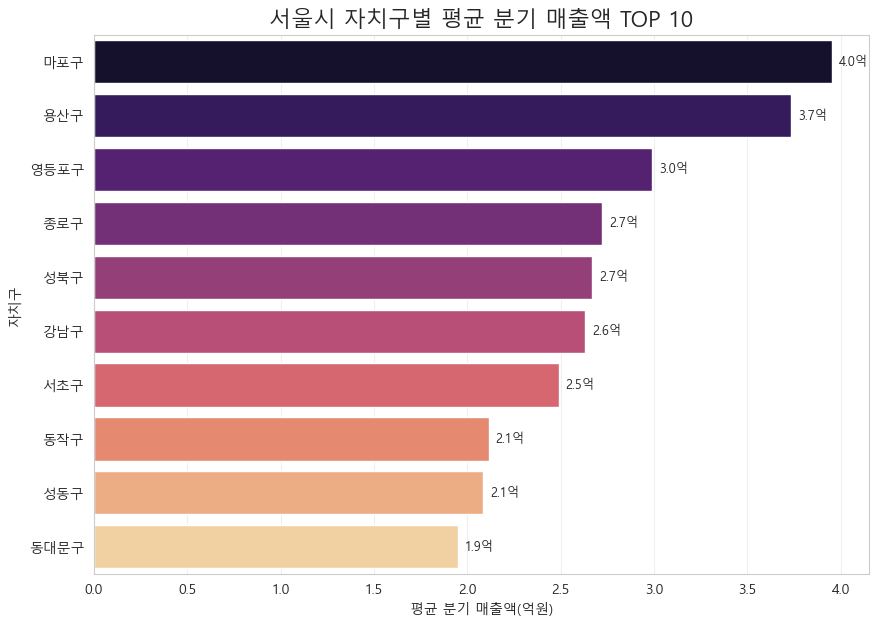

In [18]:
# 자치구별 평균 매출 계산 (억원 단위)
gu_sales_sorted = (
    df.groupby('자치구')['분기_매출금액']
    .mean()
    .sort_values(ascending=False)
    / 100000000
)

# 상위 10개 자치구만 추출
top10_gu = gu_sales_sorted.head(10)

plt.figure(figsize=(10, 7))

barplot = sns.barplot(
    x=top10_gu.values,
    y=top10_gu.index,
    palette='magma'
)

# 값 표시
for p in barplot.patches:

    width = p.get_width()

    barplot.annotate(
        f'{width:.1f}억',
        (width, p.get_y() + p.get_height() / 2),
        ha='left',
        va='center',
        fontsize=9,
        xytext=(5, 0),
        textcoords='offset points'
    )

plt.title(
    '서울시 자치구별 평균 분기 매출액 TOP 10',
    fontsize=16
)

plt.xlabel('평균 분기 매출액(억원)')
plt.ylabel('자치구')

plt.grid(axis='x', alpha=0.3)

plt.show()

In [19]:
gu_sales_rank = df.groupby('자치구')['분기_매출금액'].mean().sort_values(ascending=False)

quantiles = gu_sales_rank.quantile([0.3, 0.7]).to_dict()
tier_low = quantiles[0.3]
tier_high = quantiles[0.7]

def assign_tier(gu_name):
    avg_sale = gu_sales_rank.loc[gu_name]
    if avg_sale >= tier_high:
        return '상위'
    elif avg_sale < tier_low:
        return '하위'
    else:
        return '중위'


df['상권_등급'] = df['자치구'].apply(assign_tier) 

### 분석 결과

자치구별 평균 매출 수준을 비교한 결과, 지역 간 매출 격차가 뚜렷하게 나타났다.

특히 마포구, 용산구, 영등포구 등 주요 상권 밀집 지역은 상대적으로 높은 평균 매출 수준을 보였으며, 이는 유동인구와 상권 활성도가 높은 지역 특성이 반영된 결과로 해석할 수 있다.

반면 일부 외곽 지역은 상대적으로 낮은 매출 수준을 보였으며, 지역별 소비 규모와 상권 밀도의 차이가 존재함을 확인할 수 있었다.

이에 따라 자치구별 평균 매출 수준을 기준으로 `상권 등급(상·중·하)`을 구분하여, 지역 특성을 반영한 파생 변수로 활용하였다.

## 3-8. 상권 규모 및 집객시설과 매출 관계 분석

카페 매출은 상권 규모와 주변 상업 인프라의 영향을 받을 가능성이 존재한다.

이에 따라 총 커피매장 수, 일반음식점 점포 수, 집객시설 수와
분기 매출금액 간의 관계를 분석하였다.

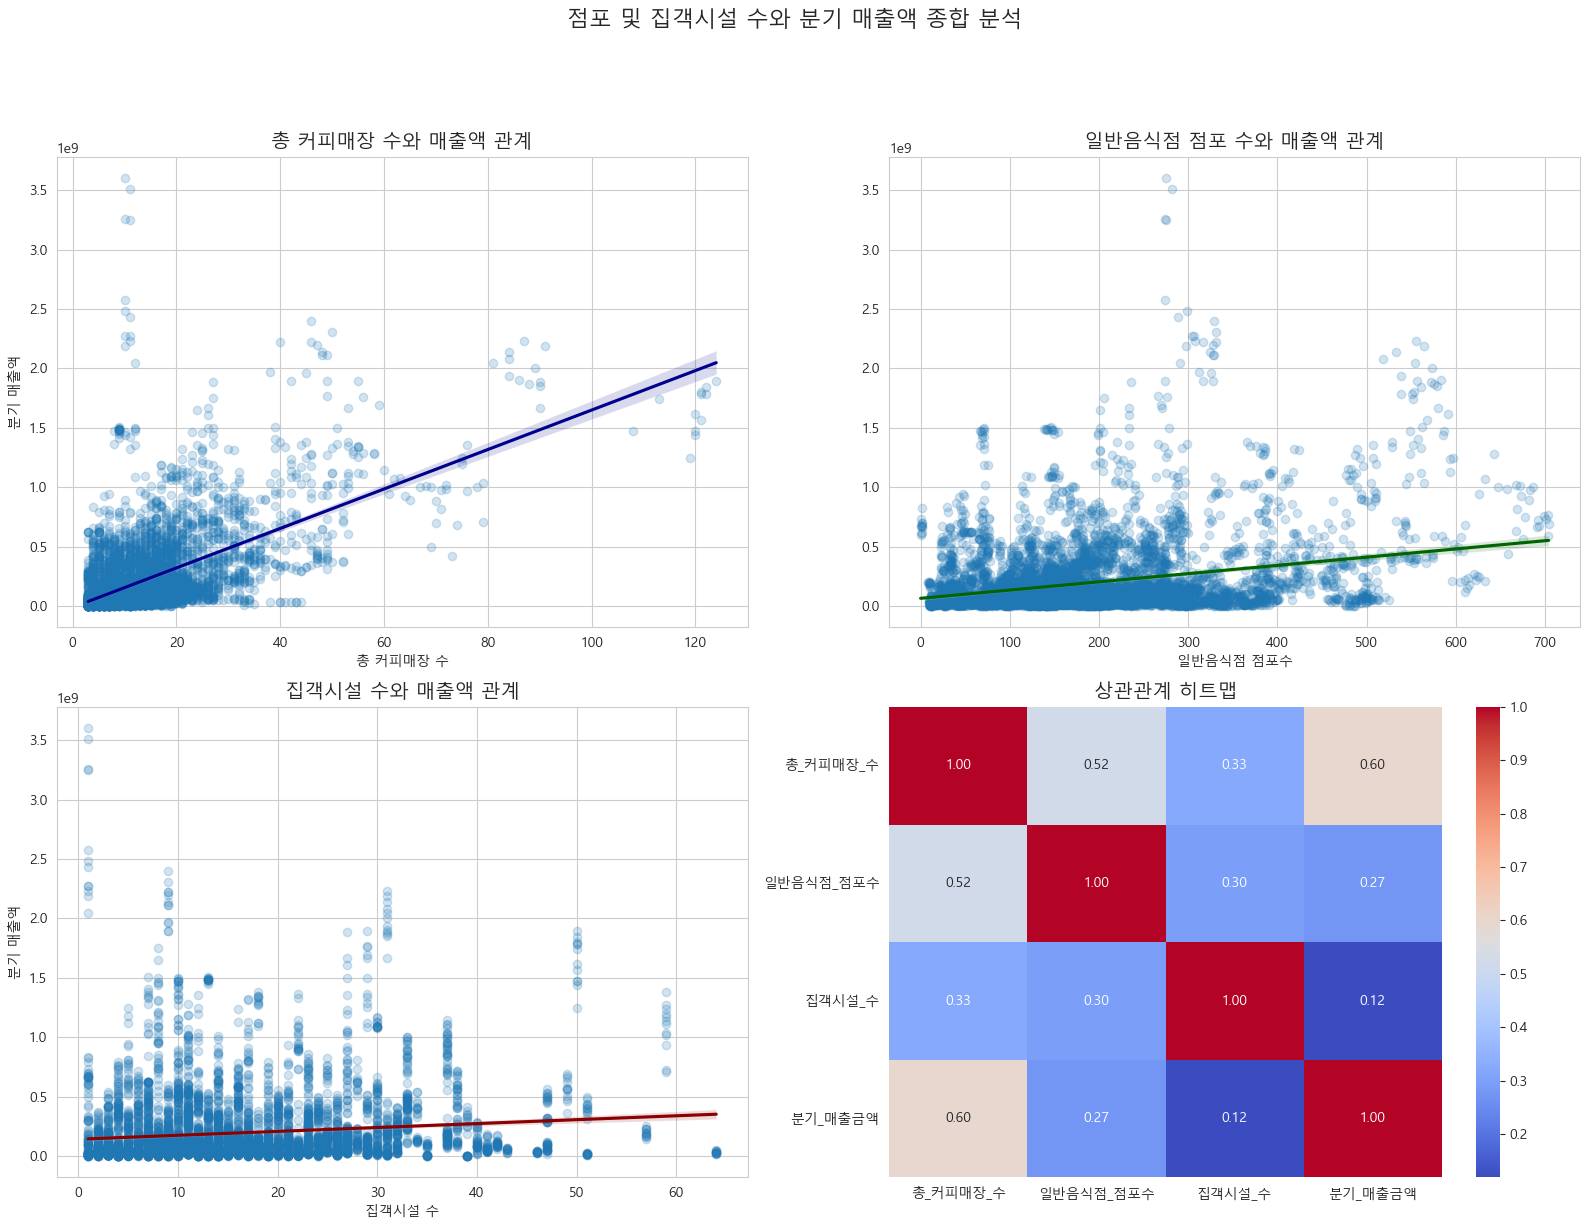

In [20]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('점포 및 집객시설 수와 분기 매출액 종합 분석', fontsize=16, y=1.02)


# --- 1행 1열: 총 커피매장 수 vs 매출액 ---
sns.regplot(
    ax=axes[0, 0],
    data=df,
    x='총_커피매장_수',
    y='분기_매출금액',
    scatter_kws={'alpha': 0.2},
    line_kws={'color': 'darkblue'}
)
axes[0, 0].set_title('총 커피매장 수와 매출액 관계', fontsize=14)
axes[0, 0].set_xlabel('총 커피매장 수')
axes[0, 0].set_ylabel('분기 매출액')
axes[0, 0].grid(True)


# --- 1행 2열: 일반음식점 점포 수 vs 매출액 ---
sns.regplot(
    ax=axes[0, 1],
    data=df,
    x='일반음식점_점포수',
    y='분기_매출금액',
    scatter_kws={'alpha': 0.2},
    line_kws={'color': 'darkgreen'}
)
axes[0, 1].set_title('일반음식점 점포 수와 매출액 관계', fontsize=14)
axes[0, 1].set_xlabel('일반음식점 점포수')
axes[0, 1].set_ylabel('')
axes[0, 1].grid(True)


# --- 2행 1열: 집객시설 수 vs 매출액 ---
sns.regplot(
    ax=axes[1, 0],
    data=df,
    x='집객시설_수',
    y='분기_매출금액',
    scatter_kws={'alpha': 0.2},
    line_kws={'color': 'darkred'}
)
axes[1, 0].set_title('집객시설 수와 매출액 관계', fontsize=14)
axes[1, 0].set_xlabel('집객시설 수')
axes[1, 0].set_ylabel('분기 매출액')
axes[1, 0].grid(True)


# --- 2행 2열: 상관관계 히트맵 ---
analysis_cols = ['총_커피매장_수', '일반음식점_점포수', '집객시설_수', '분기_매출금액']
correlation_matrix = df[analysis_cols].corr()
sns.heatmap(
    ax=axes[1, 1],
    data=correlation_matrix,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)
axes[1, 1].set_title('상관관계 히트맵', fontsize=14)


plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

### 분석 결과

상권 규모 및 주변 상업 인프라 변수와 분기 매출금액 간의 관계를 확인한 결과, `총_커피매장_수`가 매출과 가장 높은 양의 상관관계를 보였다.

이는 커피매장 수가 많은 지역일수록 단순히 경쟁이 심한 지역이라기보다, 카페 소비 수요가 이미 형성된 목적지형 상권일 가능성이 높다는 점을 시사한다.

반면 일반음식점 점포 수와 집객시설 수는 상대적으로 낮은 상관관계를 보였다. 이는 상업시설의 단순 개수보다 카페 업종 자체의 밀집도와 소비 수요가 매출 설명에 더 중요한 영향을 미칠 수 있음을 의미한다.

따라서 이후 모델링 과정에서는 `총_커피매장_수`를 핵심 설명 변수로 활용하고, 일반음식점 및 집객시설 변수는 상권 보조 특성 변수로 함께 고려한다.

## 3-9. 상주인구와 매출 관계 분석

카페 매출은 상권 내 거주 인구 규모와 소비 특성의 영향을 받을 가능성이 존재한다.

이에 따라 총 상주인구 및 연령대별 상주인구와
분기 매출금액 간의 관계를 분석하였다.

In [21]:
resident_age_cols = [
    '연령대_10_상주인구_수',
    '연령대_20_상주인구_수',
    '연령대_30_상주인구_수',
    '연령대_40_상주인구_수',
    '연령대_50_상주인구_수',
    '연령대_60_이상_상주인구_수'
]

resident_corr = (
    df[resident_age_cols + ['분기_매출금액']]
    .corr(method='pearson')
)

sales_corr = resident_corr['분기_매출금액'].drop('분기_매출금액')

sales_corr = sales_corr.reindex(
    sales_corr.abs().sort_values(ascending=False).index
)

resident_corr_df = sales_corr.to_frame(name='Correlation')

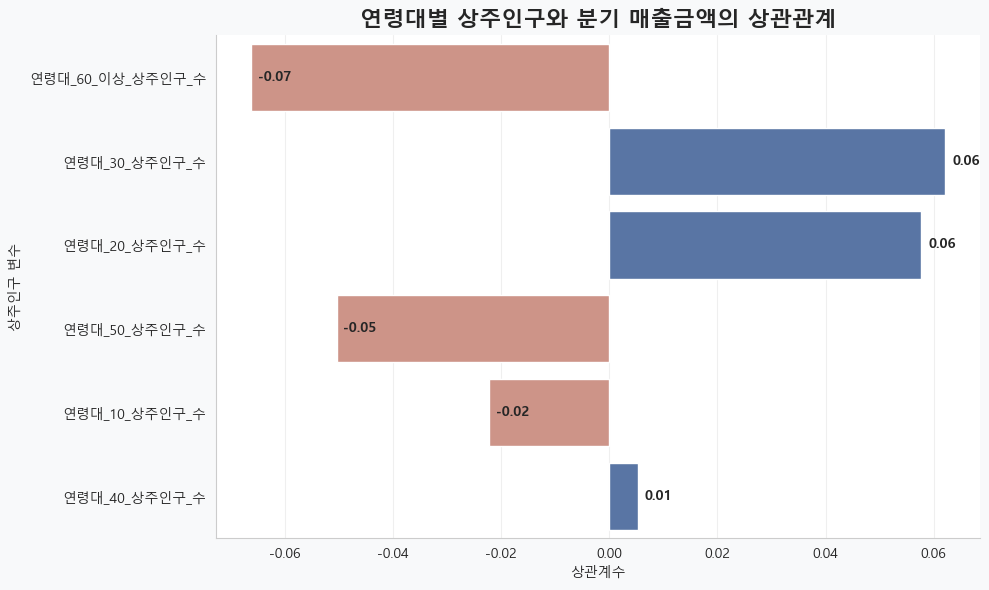

In [22]:
fig, ax = plt.subplots(figsize=(10, 6))

fig.patch.set_facecolor('#f8f9fa')

barplot = sns.barplot(
    x='Correlation',
    y=resident_corr_df.index,
    data=resident_corr_df,
    palette=[
    '#4C72B0' if x > 0 else '#D98C7C'
    for x in resident_corr_df['Correlation']
],
    ax=ax
)

# 값 표시
for p in barplot.patches:

    width = p.get_width()

    barplot.annotate(
        f'{width:.2f}',
        (width, p.get_y() + p.get_height() / 2),
        ha='left',
        va='center',
        fontsize=10,
        fontweight='bold',
        xytext=(5, 0),
        textcoords='offset points'
    )

ax.set_title(
    '연령대별 상주인구와 분기 매출금액의 상관관계',
    fontsize=16,
    fontweight='bold'
)

ax.set_xlabel('상관계수')
ax.set_ylabel('상주인구 변수')

ax.grid(axis='x', alpha=0.3)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()

plt.show()

### 분석 결과

연령대별 상주인구와 매출 간 상관관계를 분석한 결과, 20~30대 상주인구는 분기 매출금액과 약한 양의 상관관계를 나타냈다.

이는 젊은 연령층이 카페 주요 소비층과 일부 연관될 가능성을 시사한다.

반면 50~60대 이상 상주인구는 약한 음의 관계를 보였으며, 연령대별 소비 패턴 차이가 상권 매출 구조에 일부 영향을 미칠 가능성을 확인할 수 있었다.

다만 전체적으로 상관계수 크기는 매우 낮은 수준(-0.07 ~ 0.06)으로 나타났으며, 상주인구 변수만으로 카페 매출 수준을 충분히 설명하기에는 한계가 존재한다.

이는 카페 매출이 단순 거주 인구 규모보다 `유동인구·직장인구·상권 활성도`와 같은 복합적 요인의 영향을 더 크게 받을 가능성을 시사한다.

## 3-10. 직장인구와 매출 관계 분석

카페 산업은 오피스 상권과 업무 활동의 영향을 크게 받을 가능성이 존재한다.

이에 따라 총 직장인구 및 연령대별 직장인구와
분기 매출금액 간의 관계를 분석하였다.

In [23]:
worker_age_cols = [
    '연령대_10_직장_인구_수',
    '연령대_20_직장_인구_수',
    '연령대_30_직장_인구_수',
    '연령대_40_직장_인구_수',
    '연령대_50_직장_인구_수',
    '연령대_60_이상_직장_인구_수'
]

worker_corr = (
    df[worker_age_cols + ['분기_매출금액']]
    .corr(method='pearson')
)

sales_corr = worker_corr['분기_매출금액'].drop('분기_매출금액')

# 절댓값 기준 정렬
sales_corr = sales_corr.reindex(
    sales_corr.abs().sort_values(ascending=False).index
)

worker_corr_df = sales_corr.to_frame(name='Correlation')

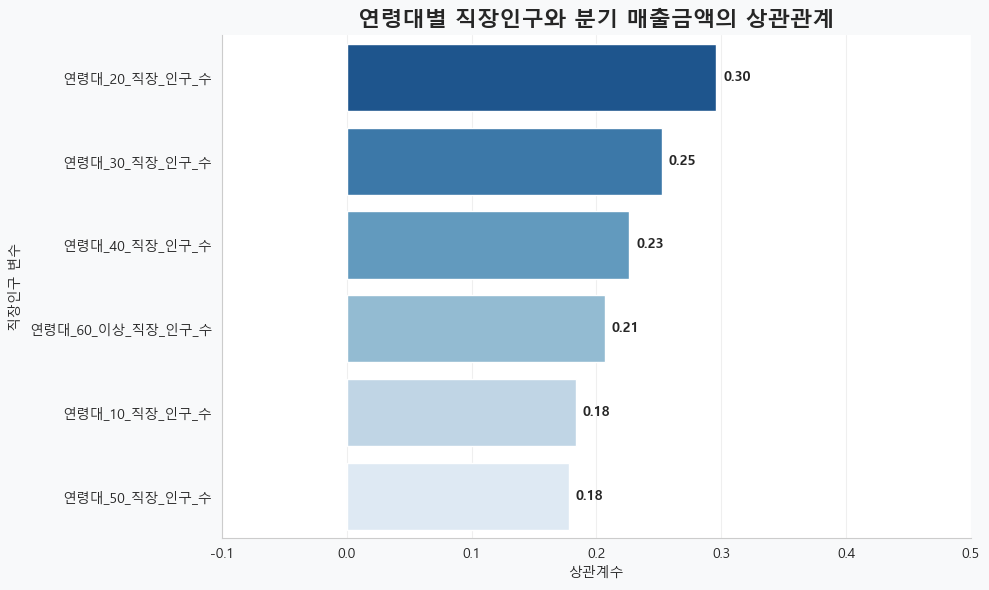

In [24]:
fig, ax = plt.subplots(figsize=(10, 6))

fig.patch.set_facecolor('#f8f9fa')

barplot = sns.barplot(
    x='Correlation',
    y=worker_corr_df.index,
    data=worker_corr_df,
    palette='Blues_r',
    ax=ax
)

# 값 표시
for p in barplot.patches:

    width = p.get_width()

    barplot.annotate(
        f'{width:.2f}',
        (width, p.get_y() + p.get_height() / 2),
        ha='left',
        va='center',
        fontsize=10,
        fontweight='bold',
        xytext=(5, 0),
        textcoords='offset points'
    )

ax.set_title(
    '연령대별 직장인구와 분기 매출금액의 상관관계',
    fontsize=16,
    fontweight='bold'
)

ax.set_xlabel('상관계수')
ax.set_ylabel('직장인구 변수')

ax.grid(axis='x', alpha=0.3)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

ax.set_xlim(-0.1, 0.5)

plt.tight_layout()

plt.show()

### 분석 결과

직장인구 변수는 상주인구 변수 대비 상대적으로 높은 상관관계를 나타냈다.

특히 20~30대 직장인구는 분기 매출금액과 비교적 높은 양의 상관관계(0.25~0.30 수준)를 보였으며, 이는 업무 활동 기반 소비가 카페 매출에 중요한 영향을 미칠 가능성을 시사한다.

반면 상주인구 변수는 전반적으로 낮은 상관관계를 보였으며, 카페 산업은 단순 거주 인구보다 실제 활동 인구와 소비 이동 흐름의 영향을 더 크게 받을 가능성이 확인되었다.

이는 카페 입지 선정 시 주거 밀집 지역뿐 아니라, 오피스 상권 및 직장인구 유입 규모를 함께 고려할 필요가 있음을 보여준다.

## 3-11. 유동인구와 매출 관계 분석


카페 산업은 실제 사람의 이동량과 활동 패턴의 영향을 크게 받을 가능성이 존재한다.

이에 따라 총 유동인구와 시간대·요일별 유동인구 특성이
분기 매출금액과 어떤 관계를 가지는지 분석하였다.

In [25]:
floating_cols = [
    '총_유동인구_수',
    '남성_유동인구_수',
    '여성_유동인구_수'
]

floating_corr = (
    df[floating_cols + ['분기_매출금액']]
    .corr(method='pearson')
)

sales_corr = floating_corr['분기_매출금액'].drop('분기_매출금액')

floating_corr_df = sales_corr.to_frame(name='Correlation')

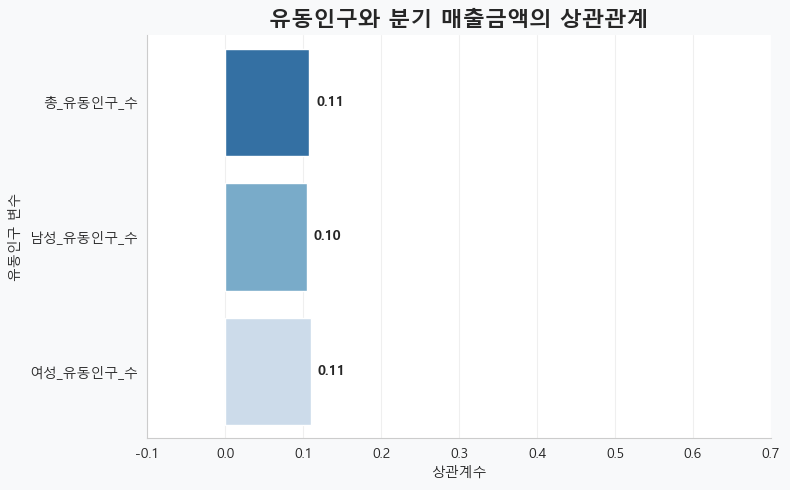

In [26]:
fig, ax = plt.subplots(figsize=(8, 5))

fig.patch.set_facecolor('#f8f9fa')

barplot = sns.barplot(
    x='Correlation',
    y=floating_corr_df.index,
    data=floating_corr_df,
    palette='Blues_r',
    ax=ax
)

# 값 표시
for p in barplot.patches:

    width = p.get_width()

    barplot.annotate(
        f'{width:.2f}',
        (width, p.get_y() + p.get_height() / 2),
        ha='left',
        va='center',
        fontsize=10,
        fontweight='bold',
        xytext=(5, 0),
        textcoords='offset points'
    )

ax.set_title(
    '유동인구와 분기 매출금액의 상관관계',
    fontsize=16,
    fontweight='bold'
)

ax.set_xlabel('상관계수')
ax.set_ylabel('유동인구 변수')
ax.set_xlim(-0.1, 0.7)
ax.grid(axis='x', alpha=0.3)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

ax.set_xlim(-0.1, 0.7)

plt.tight_layout()

plt.show()

### 분석 결과

총 유동인구 변수는 분기 매출금액과 약한 양의 상관관계를 나타냈다.

다만 상관계수 수준은 0.10~0.11 수준으로 비교적 낮게 나타났으며, 단순 유동인구 규모만으로 카페 매출 수준을 충분히 설명하기에는 한계가 존재했다.

이는 카페 산업이 단순 이동량 자체보다, 실제 체류 목적·업무 활동·소비 행동이 결합된 활동 인구 특성의 영향을 더 크게 받을 가능성을 시사한다.

특히 이전 직장인구 분석 결과와 비교했을 때, 카페 매출은 단순 유동 규모보다 오피스 기반 소비 흐름과 더 밀접한 관련을 가질 가능성이 확인되었다.

이에 따라 다음 단계에서는 `시간대 및 요일별 유동인구 특성`을 추가적으로 분석하였다.

## 3-12. 시간대별 유동인구와 매출 관계 분석

카페 산업은 시간대별 활동 패턴과 생활 동선의 영향을 크게 받을 가능성이 존재한다.

이에 따라 시간대별 유동인구와 분기 매출금액 간의 관계를 분석하여,
어떤 시간대의 활동 인구가 카페 매출과 높은 관련성을 가지는지 확인하였다.

In [27]:
time_cols = [
    '시간대_00_06_유동인구_수',
    '시간대_06_11_유동인구_수',
    '시간대_11_14_유동인구_수',
    '시간대_14_17_유동인구_수',
    '시간대_17_21_유동인구_수',
    '시간대_21_24_유동인구_수'
]

time_corr = (
    df[time_cols + ['분기_매출금액']]
    .corr(method='pearson')
)

sales_corr = time_corr['분기_매출금액'].drop('분기_매출금액')

# 절댓값 기준 정렬
sales_corr = sales_corr.reindex(
    sales_corr.abs().sort_values(ascending=False).index
)

time_corr_df = sales_corr.to_frame(name='Correlation')

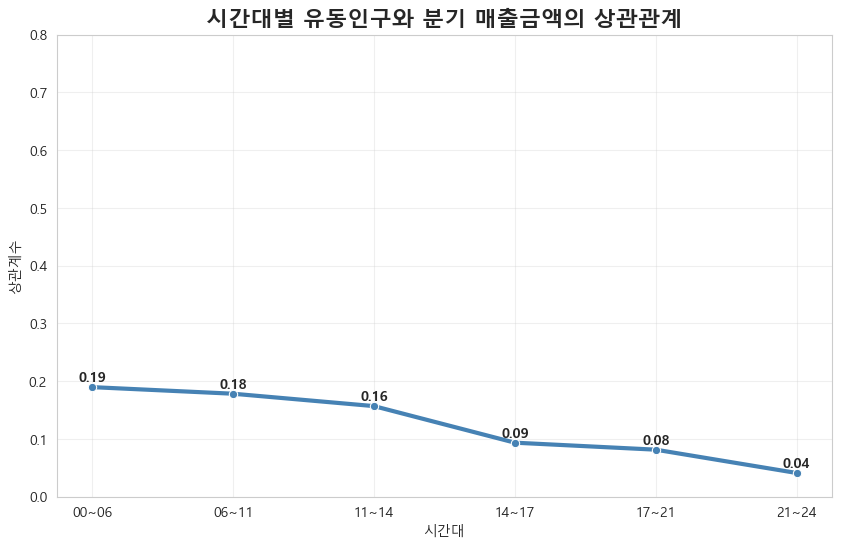

In [28]:
time_labels = [
    '00~06',
    '06~11',
    '11~14',
    '14~17',
    '17~21',
    '21~24'
]

plt.figure(figsize=(10, 6))

sns.lineplot(
    x=time_labels,
    y=time_corr_df['Correlation'],
    marker='o',
    linewidth=3,
    color='steelblue'
)

# 값 표시
for i, value in enumerate(time_corr_df['Correlation']):

    plt.text(
        i,
        value + 0.01,
        f'{value:.2f}',
        ha='center',
        fontsize=10,
        fontweight='bold'
    )

plt.title(
    '시간대별 유동인구와 분기 매출금액의 상관관계',
    fontsize=16,
    fontweight='bold'
)

plt.xlabel('시간대')
plt.ylabel('상관계수')

plt.grid(True, alpha=0.3)

plt.ylim(0, 0.8)

plt.show()

### 분석 결과

시간대별 유동인구와 매출 간 관계를 분석한 결과, `오전 시간대 유동인구`가 상대적으로 높은 상관관계를 나타냈다.

특히 00~06시 및 06~11시 시간대 유동인구는 다른 시간대 대비 비교적 높은 관계를 보여, 업무 시작 전 이동·출근 동선·아침 소비 활동과 카페 매출이 일정 부분 연관될 가능성을 시사한다.

반면 오후 및 야간 시간대로 갈수록 상관관계가 점차 낮아지는 경향이 나타났으며, 이는 카페 소비가 저녁 활동보다 주간 업무 및 이동 중심 소비 패턴의 영향을 더 크게 받을 가능성을 보여준다.

다만 전체 상관계수 수준은 0.04~0.19 수준으로 매우 높은 편은 아니며, 시간대 유동인구 역시 단독 변수보다는 **직장인구·상권 특성·업무 밀집도와 함께 해석**할 필요가 있다.

### **EDA 종합 인사이트**

EDA 결과, 카페 매출은 단순 거주 인구 규모보다 상권 활성도·직장인구·시간대 활동 패턴과 더 밀접한 관계를 보이는 것으로 나타났다.

특히 총 커피매장 수와 직장인구 변수는 상대적으로 높은 상관관계를 보였으며, 이는 카페 소비가 업무 활동 및 상업 중심지 기반 소비 흐름의 영향을 크게 받을 가능성을 시사한다.

반면 날씨 변수·단순 유동인구 규모·상주인구 변수는 상대적으로 낮은 설명력을 보였으며, 카페 매출은 단일 변수보다 복합적인 상권 구조의 영향을 받는 것으로 해석할 수 있었다.

또한 상권 변화 지표 분석 결과, 성장성과 상권 활성도가 높은 지역일수록 상대적으로 높은 매출 수준을 보이는 경향이 확인되었다.

이러한 결과를 바탕으로 이후 모델링 단계에서는 상권 활성도·직장인구·커피매장 밀집도·시간대 활동 특성을 중심으로 주요 변수를 구성하였다.

#  **Feature Engineering**

## 4-1. feature engineering
EDA 결과 단일 변수만으로는 카페 매출을 충분히 설명하기 어려웠다.

이에 따라 상권 구조·활동 인구·소비 특성을 반영할 수 있는 파생 변수를 추가 생성하여 모델 설명력을 강화하고자 하였다.


- 핵심 소비 연령층
- 시간대별 유동 패턴
- 상권 경쟁 수준
- 직장인 중심 상권 여부
등 복합적인 특성에 영향을 받을 가능성이 확인되었다.

이에 따라 비즈니스 관점을 반영한 파생변수를 생성하였다.

1. 핵심 소비층 비율
   
20~30대 직장인구는 카페 소비의 핵심 고객층일 가능성이 높다.

이에 따라 전체 직장인구 중
20~30대 직장인구 비율을 계산하여
상권 내 핵심 소비층 밀집도를 반영하였다.

In [29]:
df['핵심소비층_비율'] = (
    (df['연령대_20_직장_인구_수'] +
     df['연령대_30_직장_인구_수'])
    / df['총_직장_인구_수']
)

2. 피크타임 비율


카페 산업은 출근 및 오전 활동 시간대 소비 패턴의 영향을 받을 가능성이 존재한다.

이에 따라 새벽~오전 시간대 유동인구 비율을 계산하여,
출근 및 아침 활동 중심 상권 특성을 반영하였다.

In [30]:
df['오전활동_비율'] = (
    df['시간대_00_06_유동인구_수'] +
    df['시간대_06_11_유동인구_수']
) / df['총_유동인구_수']

3. 경쟁강도

카페 업종 비중이 높은 상권은
카페 소비 수요가 집중된 지역일 가능성이 존재한다.

이에 따라 전체 일반음식점 점포 수 대비
카페 점포 수 비율을 계산하여
상권 내 카페 경쟁 강도를 반영하였다.

In [31]:
df['경쟁강도'] = (
    df['총_커피매장_수'] /
    df['일반음식점_점포수']
)

4. 직장인 비율  : 오피스 상권 여부 , "유동 중 얼마나 업무 활동 중심인가?"

카페 매출은 단순 거주 인구보다
실제 업무 및 소비 활동 인구의 영향을 받을 가능성이 존재한다.

이에 따라 유동인구 대비 직장인구 비율을 계산하여,
활동 중심 상권 여부를 반영하였다.

In [32]:
df['직장인_비율'] = (
    df['총_직장_인구_수'] /
    df['총_유동인구_수']
)

5. 성장 상권 여부

상권 변화 지표를 기반으로 성장 가능성이 높은 상권 여부를 파생 변수로 생성하였다.

다이나믹 및 상권확장 유형은 성장 상권으로 정의하였으며, 정체 및 상권축소 유형은 일반 상권으로 구분하였다.

In [33]:
df['성장상권_여부'] = np.where(
    df['상권_변화_지표_명'].isin(['다이나믹', '상권확장']),
    1,
    0
)

In [34]:
# 생성된 파생 변수 확인

feature_cols = [
    '핵심소비층_비율',
    '오전활동_비율',
    '경쟁강도',
    '직장인_비율',
    '성장상권_여부'
]

df[feature_cols].head()

,핵심소비층_비율,오전활동_비율,경쟁강도,직장인_비율,성장상권_여부
0,0.567073,0.444410,0.181818,0.000929,0
1,0.567073,0.432830,0.181818,0.000846,0
2,0.567073,0.424301,0.190476,0.000852,0
3,0.568085,0.424643,0.166667,0.000829,0
4,0.414414,0.548187,0.109375,0.002435,0


# **모델링 준비**

In [35]:
# 최종 변수 선택

selected_cols = [

    # 기본 정보
    '년도',
    '분기',

    # 상권 구조
    '총_커피매장_수',
    '일반음식점_점포수',
    '집객시설_수',
    '상권_변화_지표_명',
    '운영_영업_개월_평균',

    # 상주인구
    '총_상주인구_수',
    '연령대_20_상주인구_수',
    '연령대_30_상주인구_수',

    # 직장인구
    '총_직장_인구_수',
    '연령대_20_직장_인구_수',
    '연령대_30_직장_인구_수',

    # 유동인구
    '총_유동인구_수',
    '시간대_00_06_유동인구_수',
    '시간대_06_11_유동인구_수',
    '시간대_11_14_유동인구_수',

    # 소비
    '월_평균_소득_금액',
    '식료품_지출_총금액',
    '여가_지출_총금액',

    # 날씨
    '평균 최고기온(℃)',
    '총 강수량(mm)',

    # 파생변수
    '핵심소비층_비율',
    '경쟁강도',
    '직장인_비율',
    '오전활동_비율',
    '성장상권_여부',

    # 타겟
    '분기_매출금액'
]

df_model = df[selected_cols].copy()

머신러닝 모델 학습을 위해
타겟 변수와 입력 변수를 분리하였다.

타겟 변수는 분기 매출금액으로 설정하였으며,
상권 특성·인구 구조·유동 패턴·파생 변수 등을 입력 변수로 활용하였다.

##  5-1.타겟 변수 및 입력 변수 분리

모델 학습을 위해 입력 변수(X)와 타겟 변수(y)를 분리하였다.

- X : 상권 구조, 인구 특성, 소비 특성, 파생 변수
- y : 분기 매출금액

In [36]:
X = df_model.drop(columns=['분기_매출금액'])
y = df_model['분기_매출금액']

## 5-2. 데이터 타입 확인

범주형 변수와 수치형 변수를 구분하기 위해 데이터 타입을 확인하였다.

특히 `년도`와 `분기` 변수는 숫자형으로 저장되어 있었지만,
실제 의미는 시기 구분에 가까우므로 범주형 변수로 변환하여 활용하였다.

In [37]:
# 년도 / 분기 문자열 변환
X['년도'] = X['년도'].astype(str)

X['분기'] = X['분기'].astype(str)

## 5-3. 범주형 변수 인코딩

머신러닝 모델은 문자열 데이터를 직접 학습할 수 없기 때문에
범주형 변수에 대해 One-Hot Encoding을 적용하였다.

또한 범주 간 순서 관계가 존재하지 않기 때문에
Label Encoding 대신 `One-Hot Encoding 방식`을 사용하였다.

In [38]:
# 범주형 변수 지정
categorical_cols = [
    '년도',
    '분기',
    '상권_변화_지표_명'
]

# One-Hot Encoding 적용
X = pd.get_dummies(
    X,
    columns=categorical_cols,
    drop_first=True
)

# bool 컬럼을 0/1로 변환
bool_cols = X.select_dtypes(include='bool').columns
X[bool_cols] = X[bool_cols].astype(int)

In [39]:
# 인코딩 결과 확인
print(X.shape)
X.head()

(7404, 32)


,총_커피매장_수,일반음식점_점포수,집객시설_수,운영_영업_개월_평균,총_상주인구_수,연령대_20_상주인구_수,연령대_30_상주인구_수,총_직장_인구_수,연령대_20_직장_인구_수,연령대_30_직장_인구_수,...,오전활동_비율,성장상권_여부,년도_2023,년도_2024,분기_2,분기_3,분기_4,상권_변화_지표_명_상권축소,상권_변화_지표_명_상권확장,상권_변화_지표_명_정체
0,4,22,18.0,111,629,57,59,492.0,138.0,141.0,...,0.444410,0,0,0,0,0,0,0,0,1
1,4,22,18.0,113,629,57,59,492.0,138.0,141.0,...,0.432830,0,0,0,1,0,0,0,0,1
2,4,21,18.0,114,629,57,59,492.0,138.0,141.0,...,0.424301,0,0,0,0,1,0,0,0,1
3,4,24,18.0,119,663,60,53,470.0,133.0,134.0,...,0.424643,0,0,0,0,0,1,0,0,1
4,7,64,18.0,108,3212,399,372,1776.0,245.0,491.0,...,0.548187,0,0,0,0,0,0,0,0,1


## 5-4. 학습용 / 테스트용 데이터 분리

모델의 일반화 성능을 검증하기 위해
데이터를 학습용(Train) 데이터와 테스트용(Test) 데이터로 분리하였다.

학습 데이터는 모델 학습에 활용하고,
테스트 데이터는 학습되지 않은 데이터에 대한 예측 성능 평가에 활용하였다.

일반적인 머신러닝 검증 방식에 따라
Train : Test = 8 : 2 비율을 적용하였다.

In [40]:
# Train / Test Split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# shape 확인
print('X_train:', X_train.shape)
print('X_test:', X_test.shape)
print('y_train:', y_train.shape)
print('y_test:', y_test.shape)

X_train: (5923, 32)
X_test: (1481, 32)
y_train: (5923,)
y_test: (1481,)


In [41]:
# inf 값을 NaN으로 변환
X_train = X_train.replace([np.inf, -np.inf], np.nan)
X_test = X_test.replace([np.inf, -np.inf], np.nan)

# 결측치 확인
print('X_train 결측치:', X_train.isnull().sum().sum())
print('X_test 결측치:', X_test.isnull().sum().sum())

# 중앙값으로 결측치 대체
X_train = X_train.fillna(X_train.median())
X_test = X_test.fillna(X_train.median())

# 최종 확인
print('처리 후 X_train 결측치:', X_train.isnull().sum().sum())
print('처리 후 X_test 결측치:', X_test.isnull().sum().sum())

X_train 결측치: 196
X_test 결측치: 46
처리 후 X_train 결측치: 0
처리 후 X_test 결측치: 0


# **모델링 및 성능 평가**

EDA 및 Feature Engineering을 통해 생성한 변수를 기반으로
카페 상권 분기 매출 예측 모델을 구축하였다.

다양한 머신러닝 알고리즘의 성능을 비교하여
최적의 예측 모델을 선정하고자 하였다.

## 6-1. Baseline Model 선정 및 학습

선형 회귀 기반 모델과 Tree 기반 Ensemble 모델을 함께 비교하였다.

- 선형 모델
  - Linear Regression
  - Ridge
  - Lasso

- Ensemble 기반 모델
  - RandomForestRegressor
  - XGBoostRegressor
  - LightGBMRegressor

이를 통해 단순 선형 관계뿐 아니라
비선형 패턴과 변수 간 상호작용까지 함께 반영하고자 하였다.

In [42]:
# 모델 불러오기
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

# 성능 평가 함수
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

# 모델 정의
models = {
    'LinearRegression': LinearRegression(),
    'Ridge': Ridge(),
    'Lasso': Lasso(),
    
    'RandomForest': RandomForestRegressor(
        random_state=42
    ),
    
    'XGBoost': XGBRegressor(
        random_state=42,
        verbosity=0
    ),
    
    'LightGBM': LGBMRegressor(
        random_state=42,
        verbose=-1
    )
}

### 모델 학습 및 예측

각 머신러닝 모델을 학습한 뒤,
테스트 데이터에 대한 예측 성능을 비교하였다.

In [43]:
# 결과 저장 리스트
results = []

# 모델 학습 및 평가
for name, model in models.items():
    
    # 학습
    model.fit(X_train, y_train)
    
    # 예측
    y_pred = model.predict(X_test)
    
    # 성능 평가
    mae = mean_absolute_error(y_test, y_pred)
    
    rmse = np.sqrt(
        mean_squared_error(y_test, y_pred)
    )
    
    r2 = r2_score(y_test, y_pred)
    
    # 결과 저장
    results.append({
        'Model': name,
        'MAE': mae,
        'RMSE': rmse,
        'R2 Score': r2
    })

# DataFrame 변환
results_df = pd.DataFrame(results)

# R2 기준 정렬
results_df = results_df.sort_values(
    by='R2 Score',
    ascending=False
)

results_df

,Model,MAE,RMSE,R2 Score
4,XGBoost,4.039593e+07,6.587001e+07,0.949215
3,RandomForest,3.679422e+07,6.893043e+07,0.944386
5,LightGBM,5.240356e+07,8.178668e+07,0.921707
1,Ridge,1.281359e+08,2.100836e+08,0.483414
0,LinearRegression,1.300638e+08,2.284696e+08,0.389036
2,Lasso,1.303635e+08,2.347006e+08,0.355256


## 성능 평가 및 비교

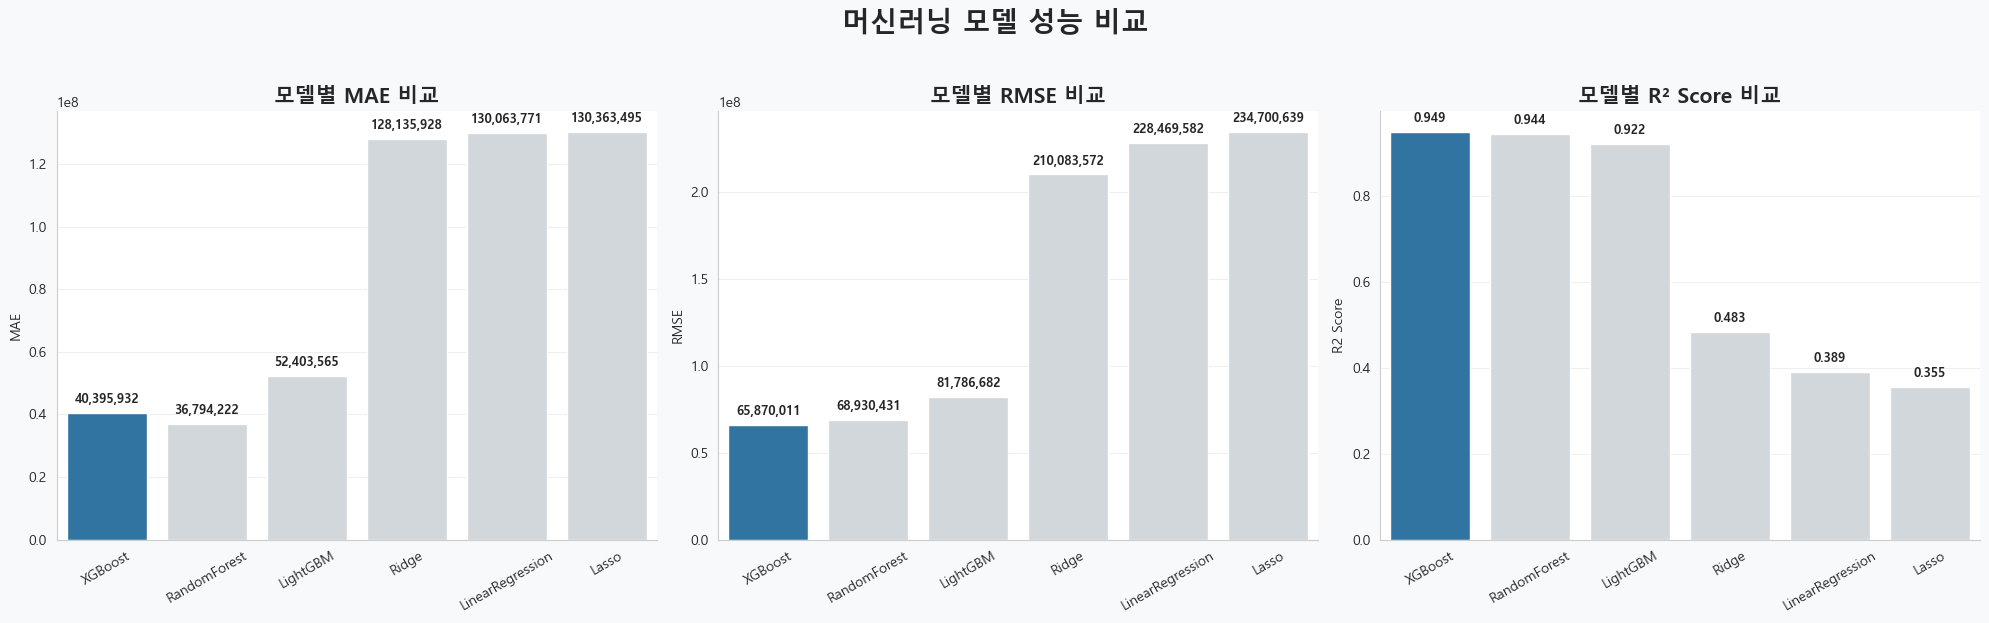

In [44]:
# figure 생성
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

fig.patch.set_facecolor('#f8f9fa')

# XGBoost 강조 색상
colors = [
    '#cfd8dc' if model != 'XGBoost' else '#1f77b4'
    for model in results_df['Model']
]

metrics = ['MAE', 'RMSE', 'R2 Score']
titles = [
    '모델별 MAE 비교',
    '모델별 RMSE 비교',
    '모델별 R² Score 비교'
]

# 반복문으로 그래프 생성
for i, metric in enumerate(metrics):

    barplot = sns.barplot(
        data=results_df,
        x='Model',
        y=metric,
        palette=colors,
        ax=axes[i]
    )

    # 제목
    axes[i].set_title(
        titles[i],
        fontsize=15,
        fontweight='bold'
    )

    axes[i].set_xlabel('')
    axes[i].set_ylabel(metric)

    # grid
    axes[i].grid(axis='y', alpha=0.3)

    # 테두리 제거
    axes[i].spines['top'].set_visible(False)
    axes[i].spines['right'].set_visible(False)

    # x축 회전
    axes[i].tick_params(axis='x', rotation=30)

    # 값 표시
    for p in barplot.patches:

        height = p.get_height()

        # R2는 소수점 표시
        if metric == 'R2 Score':
            label = f'{height:.3f}'
        else:
            label = f'{height:,.0f}'

        barplot.annotate(
            label,
            (p.get_x() + p.get_width() / 2., height),
            ha='center',
            va='bottom',
            fontsize=9,
            fontweight='bold',
            xytext=(0, 5),
            textcoords='offset points'
        )

# 전체 제목
fig.suptitle(
    '머신러닝 모델 성능 비교',
    fontsize=20,
    fontweight='bold',
    y=1.03
)

plt.tight_layout()

plt.show()

### **모델 성능 비교 결과**

모델 성능 비교 결과, XGBoost는 가장 낮은 RMSE와 가장 높은 R² Score를 기록하며 전반적으로 가장 우수한 성능을 보였다.  4

다만 MAE 기준에서는 RandomForest가 가장 낮은 오차를 보였으나, 본 프로젝트에서는 설명력과 큰 오차에 대한 안정성을 함께 고려하여 `XGBoost를 최종 모델`로 선정하였다.

최종 선정된 XGBoost 모델의 예측 성능을 시각적으로 확인하기 위해
실제 매출값과 예측 매출값의 관계를 비교하였다.

실제값과 예측값이 대각선에 가까울수록
모델이 매출 패턴을 효과적으로 학습했음을 의미한다.

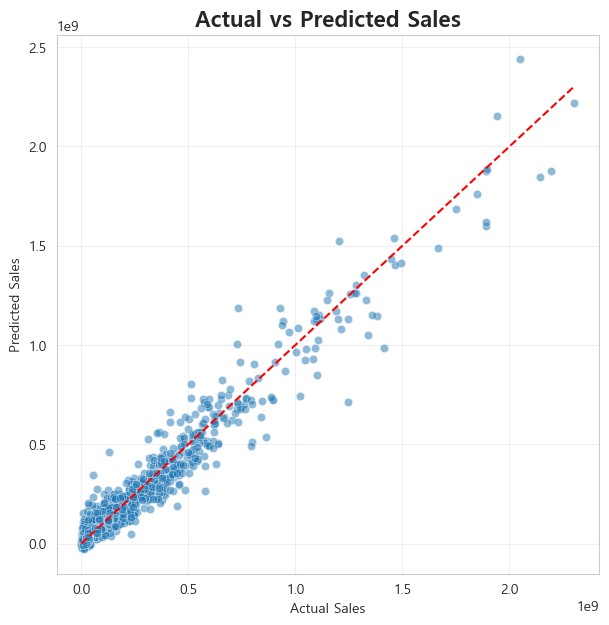

In [47]:
# 최종 모델 예측
y_pred = final_model.predict(X_test)

plt.figure(figsize=(7, 7))

sns.scatterplot(
    x=y_test,
    y=y_pred,
    alpha=0.5
)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color='red',
    linestyle='--'
)

plt.title(
    'Actual vs Predicted Sales',
    fontsize=16,
    fontweight='bold'
)

plt.xlabel('Actual Sales')
plt.ylabel('Predicted Sales')

plt.grid(alpha=0.3)

plt.show()

## 6-2. Feature Importance 분석

최종 선정된 `XGBoost 모델`을 기반으로
카페 상권 매출 예측에 영향을 미치는 주요 변수를 분석하였다.

Feature Importance를 통해
모델이 어떤 변수들을 중요하게 활용하여 매출을 예측하는지 확인하고,
실제 카페 상권의 `핵심 성공 요인`을 해석하고자 하였다.

In [45]:
# 최종 모델 정의
final_model = XGBRegressor(
    random_state=42,
    verbosity=0
)

# 학습
final_model.fit(X_train, y_train)

# Feature Importance 추출
importance_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': final_model.feature_importances_
})

# 중요도 정렬
importance_df = importance_df.sort_values(
    by='Importance',
    ascending=False
)

# 상위 15개 변수 확인
importance_df.head(15)

,Feature,Importance
0,총_커피매장_수,0.209976
22,오전활동_비율,0.120757
14,월_평균_소득_금액,0.084578
15,식료품_지출_총금액,0.065709
16,여가_지출_총금액,0.065624
19,핵심소비층_비율,0.057914
6,연령대_30_상주인구_수,0.050396
31,상권_변화_지표_명_정체,0.043483
2,집객시설_수,0.040222
7,총_직장_인구_수,0.038003


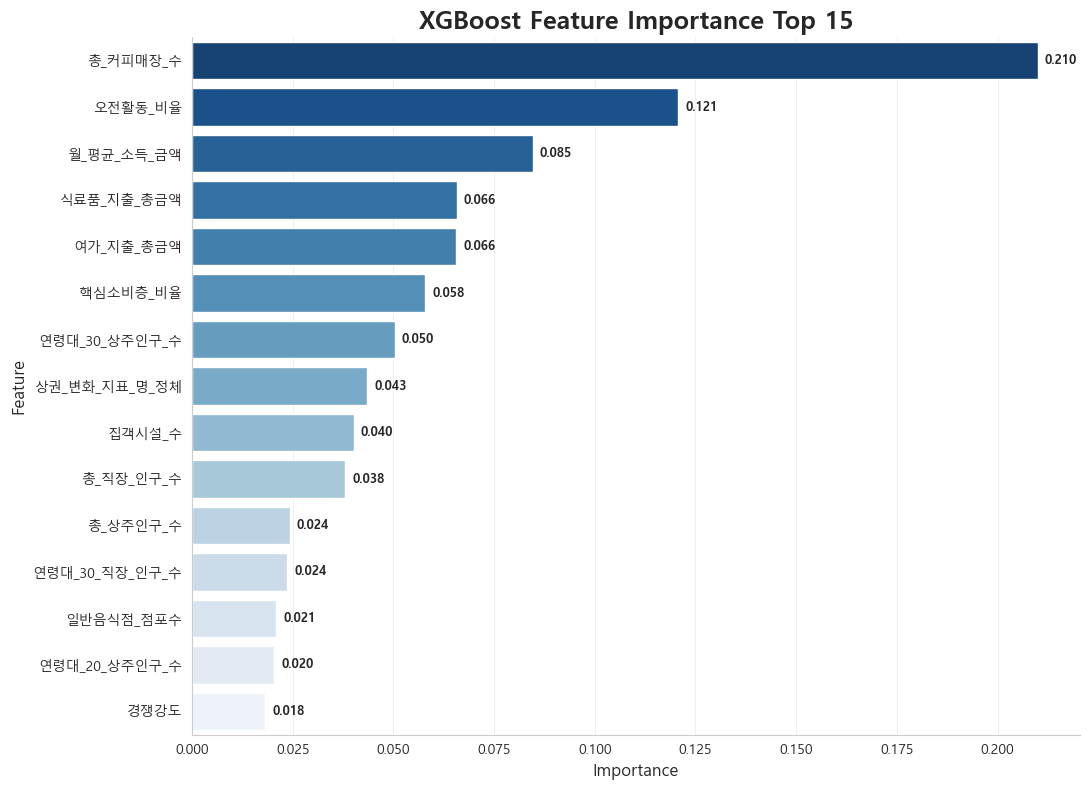

In [46]:
# 상위 15개 변수 추출
top15 = importance_df.head(15)

# 그래프 크기
plt.figure(figsize=(11, 8))


# barplot
barplot = sns.barplot(
    data=top15,
    x='Importance',
    y='Feature',
    palette='Blues_r'
)

# 제목
plt.title(
    'XGBoost Feature Importance Top 15',
    fontsize=18,
    fontweight='bold'
)

# 축 라벨
plt.xlabel('Importance', fontsize=12)
plt.ylabel('Feature', fontsize=12)

# grid
plt.grid(axis='x', alpha=0.3)

# 테두리 제거
sns.despine()

# 중요도 값 표시
for p in barplot.patches:

    width = p.get_width()

    barplot.annotate(
        f'{width:.3f}',
        (
            width,
            p.get_y() + p.get_height() / 2
        ),
        ha='left',
        va='center',
        fontsize=9,
        fontweight='bold',
        xytext=(5, 0),
        textcoords='offset points'
    )

plt.tight_layout()

plt.show()

### 분석 결과

XGBoost Feature Importance 분석 결과, `총_커피매장_수`가 가장 높은 중요도를 보였다.

이는 카페 매장이 많은 지역이 단순히 경쟁이 심한 지역이라기보다, 이미 카페 소비 수요가 형성된 활성 상권일 가능성이 높다는 점을 시사한다.

또한 `오전활동_비율`이 높은 중요도를 보이며, 출근 및 오전 시간대 이동 흐름이 카페 매출에 중요한 영향을 미칠 수 있음을 확인하였다.

소득 및 지출 관련 변수 역시 상위권에 포함되어, 상권 내 소비 여력과 생활 소비 규모가 카페 매출을 설명하는 주요 요인으로 작용하는 것으로 나타났다.

종합하면, 성공적인 카페 상권은 단순히 유동인구가 많은 지역이 아니라, 카페 소비 수요가 검증되어 있고 오전 활동 인구와 소비력이 함께 뒷받침되는 상권일 가능성이 높다.

# **비즈니스 인사이트 및 전략 제안**

### 1) 카페 수요가 이미 형성된 상권

총 커피매장 수가 가장 높은 중요도를 보인 결과,
카페 밀집 상권은 단순 경쟁 지역이 아니라
이미 소비 수요가 검증된 활성 상권일 가능성이 높았다.

이는 신규 카페 입지 선정 시
단순 경쟁 회피보다 `상권 활성도와 소비 집중도`를 함께 고려할 필요가 있음을 시사한다.


### 2) 오전 활동 인구 기반 소비 패턴

오전활동_비율이 높은 중요도를 보인 결과,
카페 소비는 단순 유동량보다 출근 및 업무 중심 이동 흐름과 밀접한 관련을 보였다.

**특히 오피스 상권 및 출근 동선 기반 지역에서
테이크아웃·출근 수요 중심 전략이 효과적일 가능성이 존재**한다.


### 3) 소비 여력이 높은 상권의 중요성

월 평균 소득 및 소비 지출 관련 변수들이 높은 중요도를 나타내며,
카페 매출은 단순 인구 규모보다 실제 소비 가능성과 생활 소비 수준의 영향을 크게 받는 것으로 나타났다.

이는 단순 유동인구 중심 입지보다
`고소득·고지출 상권 중심 전략`이 중요할 가능성을 시사한다.

# **최종 결론**

본 프로젝트에서는 서울시 카페 상권 데이터를 기반으로
매출에 영향을 미치는 주요 요인을 분석하고 예측 모델을 구축하였다.

분석 결과, 카페 매출은 단순 유동인구보다
직장인구·오전 활동 흐름·소비 수준·상권 활성도와 같은
실제 활동 기반 소비 특성의 영향을 크게 받는 것으로 나타났다.

또한 XGBoost 모델이 가장 우수한 예측 성능(R² 약 0.94)을 기록하며,
비선형적 상권 특성과 변수 간 상호작용을 효과적으로 설명하였다.

이를 통해 성공적인 카페 상권은
단순 인구 규모보다 소비 수요가 이미 검증되어 있고,
활동 인구와 소비력이 함께 집중되는 상권일 가능성이 높다는 점을 확인할 수 있었다.